In [1]:
# Instalación de librerías requeridas para lectura de SPSS y manipulación de datos
!pip install pyreadstat pandas numpy matplotlib seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 34.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import pyreadstat
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración para mostrar todas las columnas en pantalla
pd.set_option('display.max_columns', None)
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [35]:
# ==========================================
# CELDA 3: CARGA Y EXPLORACIÓN INICIAL
# ==========================================

# 1. Cargar los datasets en formato SPSS (.sav)
# La función read_sav devuelve el DataFrame y la metadata con las etiquetas
df_persona, meta_persona = pyreadstat.read_sav('EH2025_Persona.sav')
df_vivienda, meta_vivienda = pyreadstat.read_sav('EH2025_Vivienda_1.sav')
df_discriminacion, meta_disc = pyreadstat.read_sav('EH2025_Discriminacion.sav')

# 2. Estandarizar nombres de columnas a minúsculas para evitar inconsistencias
df_persona.columns = df_persona.columns.str.lower()
df_vivienda.columns = df_vivienda.columns.str.lower()
df_discriminacion.columns = df_discriminacion.columns.str.lower()

# 3. Mostrar dimensiones de cada dataset (Filas x Columnas)
print("=== DIMENSIONES DE LOS DATASETS ===")
print(f"Tabla Persona:        {df_persona.shape[0]} registros (filas) y {df_persona.shape[1]} variables (columnas)")
print(f"Tabla Vivienda:       {df_vivienda.shape[0]} registros (filas) y {df_vivienda.shape[1]} variables (columnas)")
print(f"Tabla Discriminación: {df_discriminacion.shape[0]} registros (filas) y {df_discriminacion.shape[1]} variables (columnas)")
print("-" * 50)

# 4. Inspección de tipos de datos de la tabla clave (Discriminación)
print("\n=== TIPOS DE DATOS (MÓDULO DISCRIMINACIÓN) ===")
print(df_discriminacion.dtypes.head(15))
print("-" * 50)

# 5. Vista previa de los primeros 5 registros de Discriminación
print("\n=== PRIMEROS 5 REGISTROS DE DISCRIMINACIÓN ===")
df_discriminacion.head()

=== DIMENSIONES DE LOS DATASETS ===
Tabla Persona:        39485 registros (filas) y 276 variables (columnas)
Tabla Vivienda:       12726 registros (filas) y 64 variables (columnas)
Tabla Discriminación: 12358 registros (filas) y 44 variables (columnas)
--------------------------------------------------

=== TIPOS DE DATOS (MÓDULO DISCRIMINACIÓN) ===
folio        object
depto       float64
area        float64
nro         float64
s09a_01a    float64
s09a_01b    float64
s09a_01c    float64
s09a_01d    float64
s09a_01e    float64
s09a_01f    float64
s09a_01g    float64
s09a_01h    float64
s09a_01i    float64
s09a_01j    float64
s09a_01k    float64
dtype: object
--------------------------------------------------

=== PRIMEROS 5 REGISTROS DE DISCRIMINACIÓN ===


,folio,depto,area,nro,s09a_01a,s09a_01b,s09a_01c,s09a_01d,s09a_01e,s09a_01f,s09a_01g,s09a_01h,s09a_01i,s09a_01j,s09a_01k,s09a_01l,s09a_01le,s09a_02,s09a_03_1,s09a_03_2,s09a_03_3,s09a_03_4,s09a_03_5,s09a_03_5e,s09a_04,s09a_04e,s09a_05_1,s09a_05_2,s09a_05_3,s09a_05_4,s09a_05_5,s09a_05_6,s09a_05_7,s09a_05_8,s09a_05_8e,s09b_01,s09b_02a,s09b_02b,s09b_02e,s09b_03,s09b_04,upm,estrato,ponderador
0,114-002315-A-0061,1.0,1.0,5.0,2.0,2.0,2.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,,2.0,NaN,NaN,NaN,NaN,NaN,,NaN,,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,,1.0,8.0,NaN,,NaN,3.0,114-002315-A,114,0.789196
1,114-002315-A-0091,1.0,1.0,4.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,3.0,8.0,NaN,,NaN,4.0,114-002315-A,114,0.789196
2,114-002315-A-0081,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,3.0,8.0,NaN,,NaN,2.0,114-002315-A,114,0.789196
3,114-002315-A-0071,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,3.0,8.0,NaN,,NaN,2.0,114-002315-A,114,0.789196
4,114-002315-A-0021,1.0,1.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,2.0,8.0,NaN,,NaN,2.0,114-002315-A,114,0.789196


In [7]:
# Análisis de valores faltantes por tabla
print("--- VALORES FALTANTES EN PERSONA (TOP 5 COLUMNAS) ---")
print(df_persona.isnull().sum().sort_values(ascending=False).head(5))

print("\n--- VALORES FALTANTES EN DISCRIMINACIÓN (TOP 5 COLUMNAS) ---")
print(df_discriminacion.isnull().sum().sort_values(ascending=False).head(5))

# Resumen estadístico descriptivo
print("\n--- ESTADÍSTICOS DESCRIPTIVOS (DISCRIMINACIÓN) ---")
df_discriminacion.describe()

--- VALORES FALTANTES EN PERSONA (TOP 5 COLUMNAS) ---
s04f_32c1    39477
s04f_32a1    39470
s04c_21e1    39466
s04c_21e2    39466
s04f_32b1    39449
dtype: int64

--- VALORES FALTANTES EN DISCRIMINACIÓN (TOP 5 COLUMNAS) ---
s09a_03_3    12270
s09a_03_4    12270
s09a_03_2    12270
s09a_03_1    12270
s09a_03_5    12270
dtype: int64

--- ESTADÍSTICOS DESCRIPTIVOS (DISCRIMINACIÓN) ---


,depto,area,nro,s09a_01a,s09a_01b,s09a_01c,s09a_01d,s09a_01e,s09a_01f,s09a_01g,s09a_01h,s09a_01i,s09a_01j,s09a_01k,s09a_01l,s09a_02,s09a_03_1,s09a_03_2,s09a_03_3,s09a_03_4,s09a_03_5,s09a_04,s09a_05_1,s09a_05_2,s09a_05_3,s09a_05_4,s09a_05_5,s09a_05_6,s09a_05_7,s09a_05_8,s09b_01,s09b_02a,s09b_02b,s09b_03,s09b_04,ponderador
count,12358.000000,12358.000000,12358.000000,12358.000000,12358.000000,12358.000000,12358.000000,12358.000000,12358.000000,12358.000000,12358.000000,12358.00000,12358.000000,12358.000000,12358.000000,2030.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,1942.000000,1942.000000,1942.000000,1942.000000,1942.00000,1942.000000,1942.000000,1942.000000,12358.000000,12358.000000,135.000000,1637.000000,12358.000000,12358.000000
mean,4.347548,1.247370,1.700518,1.973782,1.994983,1.993688,2.008335,1.967875,1.986891,1.987700,1.976614,2.00089,1.992717,1.967228,2.012381,1.956650,1.318182,1.693182,1.693182,1.943182,1.863636,2.045455,1.827497,1.795057,1.812049,1.461895,1.72966,1.727085,1.524202,1.949022,2.457517,7.199061,3.311111,1.819792,3.127205,1.000000
std,2.372018,0.431501,1.088115,0.236560,0.192034,0.181598,0.157400,0.244424,0.195000,0.175853,0.233588,0.13067,0.156162,0.274592,0.227065,0.203693,0.468440,0.463816,0.463816,0.232822,0.345141,0.895828,0.377914,0.403764,0.390773,0.498674,0.44425,0.445572,0.499543,0.220010,0.737618,2.118645,1.712407,0.384478,0.954328,0.709079
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.045924
25%,2.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.00000,1.000000,1.000000,2.000000,2.000000,8.000000,2.000000,2.000000,2.000000,0.577296
50%,4.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.00000,2.000000,2.000000,2.000000,3.000000,8.000000,3.000000,2.000000,3.000000,0.842672
75%,7.000000,1.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,2.000000,3.000000,8.000000,4.000000,2.000000,4.000000,1.229326
max,9.000000,2.000000,10.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.00000,4.000000,4.000000,4.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,5.000000,2.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,2.000000,4.000000,8.000000,8.000000,2.000000,5.000000,7.636526


In [8]:
# Identificamos columnas relativas a discriminación (módulo S09A)
cols_disc = [c for c in df_discriminacion.columns if c.startswith('s09a_01')]

# Función para categorizar la discriminación
def calcular_discriminacion(row):
    for col in cols_disc:
        val = row[col]
        # En SPSS/INE, el valor 1 suele representar 'Sí'
        if val == 1 or val == '1' or str(val).strip().lower() in ['sí', 'si']:
            return 1
    return 0

df_discriminacion['percepcion_discriminacion'] = df_discriminacion.apply(calcular_discriminacion, axis=1)

# Identificamos columnas relativas a victimización (módulo S09B)
cols_sec = [c for c in df_discriminacion.columns if c.startswith('s09b_02') or c.startswith('s09b_01')]

def calcular_victimizacion(row):
    for col in cols_sec:
        val = row[col]
        if val in [1, '1'] or str(val).strip().lower() in ['sí', 'si']:
            return 1
    return 0

df_discriminacion['victimizacion_delito'] = df_discriminacion.apply(calcular_victimizacion, axis=1)

print("Distribución de la variable Percepcion_Discriminacion:")
print(df_discriminacion['percepcion_discriminacion'].value_counts(normalize=True) * 100)

print("\nDistribución de la variable Victimizacion_Delito:")
print(df_discriminacion['victimizacion_delito'].value_counts(normalize=True) * 100)

Distribución de la variable Percepcion_Discriminacion:
percepcion_discriminacion
0    85.232238
1    14.767762
Name: proportion, dtype: float64

Distribución de la variable Victimizacion_Delito:
victimizacion_delito
0    83.72714
1    16.27286
Name: proportion, dtype: float64


In [9]:
# Imputación justificada: Las variables numéricas sociodemográficas sin respuesta se rellenan con la mediana,
# y las categóricas con la moda o valor 'Sin Especificar'.

# Limpieza en tabla persona (ejemplo con variables clave: edad y sexo)
if 's02a_03' in df_persona.columns:  # edad
    df_persona['s02a_03'] = df_persona['s02a_03'].fillna(df_persona['s02a_03'].median())

# Eliminamos filas donde la clave primaria sea nula para evitar duplicados en el merge
df_persona = df_persona.dropna(subset=['folio', 'nro'])
df_discriminacion = df_discriminacion.dropna(subset=['folio', 'nro'])
df_vivienda = df_vivienda.dropna(subset=['folio'])

print("Limpieza e imputación básica completada.")

Limpieza e imputación básica completada.


In [10]:
# =========================================================
# CELDA 5: INGENIERÍA DE CARACTERÍSTICAS (CASO 3)
# =========================================================

import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. VARIABLE OBJETIVO 1 Y ÍNDICE DE MOTIVOS DE DISCRIMINACIÓN
# ---------------------------------------------------------
# Identificar todas las columnas de la sección S09A referentes a discriminación
cols_disc = [c for c in df_discriminacion.columns if c.startswith('s09a_01') or c.startswith('S09A_01')]

def procesar_discriminacion(row):
    conteo_motivos = 0
    for col in cols_disc:
        val = row[col]
        # Verificar si la respuesta indica 'Sí' (en SPSS el código 1 suele ser 'Sí')
        if val == 1 or val == '1' or str(val).strip().lower() in ['sí', 'si']:
            conteo_motivos += 1

    # Retorna (1 si sufrió al menos un evento de discriminación, y el total de motivos)
    hubo_discriminacion = 1 if conteo_motivos > 0 else 0
    return pd.Series([hubo_discriminacion, conteo_motivos])

# Aplicar función y crear las dos nuevas variables
df_discriminacion[['percepcion_discriminacion', 'indice_motivos_discriminacion']] = df_discriminacion.apply(
    procesar_discriminacion, axis=1
)


# ---------------------------------------------------------
# 2. VARIABLE OBJETIVO 2: VICTIMIZACIÓN POR DELITO
# ---------------------------------------------------------
# Identificar las columnas del módulo S09B sobre hechos delictivos o agresión
cols_sec = [c for c in df_discriminacion.columns if c.startswith('s09b_01') or c.startswith('s09b_02')]

def evaluar_victimizacion(row):
    for col in cols_sec:
        val = row[col]
        # Si declara haber sido víctima de un delito/agresión
        if val in [1, '1'] or str(val).strip().lower() in ['sí', 'si']:
            return 1
    return 0

df_discriminacion['victimizacion_delito'] = df_discriminacion.apply(evaluar_victimizacion, axis=1)


# ---------------------------------------------------------
# 3. ÍNDICE COMPUESTO: NIVEL DE INSEGURIDAD PERCIBIDA
# ---------------------------------------------------------
# Evaluamos la percepción de seguridad barrial (si existe la variable s09b_04 o similar)
if 's09b_04' in df_discriminacion.columns:
    # Mapeo de percepción: Muy seguro (1) a Muy inseguro (4)
    df_discriminacion['nivel_inseguridad_barrial'] = df_discriminacion['s09b_04'].astype(str).str.extract('(\d+)').astype(float)
else:
    # En caso de no existir esa columna específica, asignamos un valor base
    df_discriminacion['nivel_inseguridad_barrial'] = np.nan


# ---------------------------------------------------------
# 4. VERIFICACIÓN Y RESUMEN DE LAS NUEVAS VARIABLES
# ---------------------------------------------------------
print("=== RESUMEN DE VARIABLES DERIVADAS CREADAS ===")
print("\n1. Percepción de Discriminación (0 = No, 1 = Sí):")
print(df_discriminacion['percepcion_discriminacion'].value_counts(normalize=True).round(4) * 100)

print("\n2. Victimización por Delito (0 = No, 1 = Sí):")
print(df_discriminacion['victimizacion_delito'].value_counts(normalize=True).round(4) * 100)

print("\n3. Distribución del Índice de Motivos de Discriminación (Cantidad de motivos):")
print(df_discriminacion['indice_motivos_discriminacion'].value_counts().head(5))

print("\nPrimeros 5 registros con las nuevas características:")
df_discriminacion[['percepcion_discriminacion', 'indice_motivos_discriminacion', 'victimizacion_delito']].head()

<>:55: SyntaxWarning: invalid escape sequence '\d'
<>:55: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1284/4156246062.py:55: SyntaxWarning: invalid escape sequence '\d'
  df_discriminacion['nivel_inseguridad_barrial'] = df_discriminacion['s09b_04'].astype(str).str.extract('(\d+)').astype(float)


=== RESUMEN DE VARIABLES DERIVADAS CREADAS ===

1. Percepción de Discriminación (0 = No, 1 = Sí):
percepcion_discriminacion
0    85.23
1    14.77
Name: proportion, dtype: float64

2. Victimización por Delito (0 = No, 1 = Sí):
victimizacion_delito
0    83.73
1    16.27
Name: proportion, dtype: float64

3. Distribución del Índice de Motivos de Discriminación (Cantidad de motivos):
indice_motivos_discriminacion
0    10533
1     1026
2      408
3      172
4      114
Name: count, dtype: int64

Primeros 5 registros con las nuevas características:


,percepcion_discriminacion,indice_motivos_discriminacion,victimizacion_delito
0,0,0,1
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0


In [11]:
# =========================================================
# CELDA 7: FUSIÓN DE DATASETS (MERGE)
# =========================================================

import pandas as pd

# 1. Asegurar que las llaves primarias no tengan espacios extra y sean del mismo tipo
for df in [df_persona, df_discriminacion, df_vivienda]:
    if 'folio' in df.columns:
        df['folio'] = df['folio'].astype(str).str.strip()
    if 'nro' in df.columns:
        df['nro'] = pd.to_numeric(df['nro'], errors='coerce')

# 2. Primera Fusión: Persona + Discriminación (Nivel Individuo)
# Llave compuesta: ['folio', 'nro']
df_merge_ind = pd.merge(
    df_persona,
    df_discriminacion,
    on=['folio', 'nro'],
    how='inner',
    suffixes=('_pers', '_disc')
)

print(f"✅ Fusión 1 (Persona + Discriminación) realizada.")
print(f"   - Registros resultantes: {df_merge_ind.shape[0]:,}")

# 3. Segunda Fusión: Dataset Individual + Vivienda (Nivel Hogar)
# Llave: ['folio']
df_analitico = pd.merge(
    df_merge_ind,
    df_vivienda,
    on='folio',
    how='left',
    suffixes=('', '_viv')
)

print(f"✅ Fusión 2 (Individuos + Vivienda) realizada.")
print(f"   - Registros finales: {df_analitico.shape[0]:,}")
print(f"   - Columnas totales: {df_analitico.shape[1]}")

# 4. Verificación de integridad de la fusión
print("\n=== VERIFICACIÓN DEL DATASET ANALÍTICO ===")
print(f"¿Existen registros duplicados por individuo?: {df_analitico.duplicated(subset=['folio', 'nro']).any()}")

# Mostrar distribución de las variables objetivo en el dataset unificado
print("\nDistribución de 'percepcion_discriminacion' en el dataset unificado:")
print(df_analitico['percepcion_discriminacion'].value_counts(dropna=False))

print("\nDistribución de 'victimizacion_delito' en el dataset unificado:")
print(df_analitico['victimizacion_delito'].value_counts(dropna=False))

# Vista previa de las primeras filas del dataset analítico
df_analitico.head()

✅ Fusión 1 (Persona + Discriminación) realizada.
   - Registros resultantes: 12,358
✅ Fusión 2 (Individuos + Vivienda) realizada.
   - Registros finales: 12,358
   - Columnas totales: 385

=== VERIFICACIÓN DEL DATASET ANALÍTICO ===
¿Existen registros duplicados por individuo?: False

Distribución de 'percepcion_discriminacion' en el dataset unificado:
percepcion_discriminacion
0    10533
1     1825
Name: count, dtype: int64

Distribución de 'victimizacion_delito' en el dataset unificado:
victimizacion_delito
0    10347
1     2011
Name: count, dtype: int64


,folio,area_pers,depto_pers,nro,s01a_02,s01a_03,s01a_04a,s01a_04b,s01a_04c,s01a_05,s01a_05a,s01a_05b,s01a_05c,s01a_06,s01a_07_1,s01a_07_2,s01a_07_3,s01a_08,s01a_09,s01a_09npioc,s01a_10,s01b_11a,s01b_11b,s01b_11c,s01b_11d,s01b_11e,s01b_12,s01b_12e,s01b_13a,s01b_10a,s01b_13b,s02a_01a,s02a_01b,s02a_01e,s02a_02a,s02a_02b,s02a_02c,s02a_02d,s02a_02e,s02a_02f,s02a_02g,s02a_02h,s02a_02he,s02a_03a,s02a_03b,s02a_03c,s02a_03d,s02a_03e,s02a_04a,s02a_04b,s02a_04c,s02a_04d,s02a_05,s02b_06,s02b_06b,s02b_07,s02b_08,s02b_09a,s02b_09b,s02b_10,s02b_10e,s02b_11,s02b_12a1,s02b_12a2,s02b_12b,s02b_13,s02b_14,s02b_14a,s02c_15,s02d_16,s02d_17,s02d_17a,s03a_01,s03a_01a,s03a_02a,s03a_02c,s03a_03a,s03a_03c,s03a_04,s03a_05,s03a_05e,s03a_06a,s03a_06c,s03a_07a,s03a_07b,s03a_08,s03a_09,s03b_10,s03b_11,s03b_11e,s03b_12,s03c_13,s03c_13a,s03c_14,s03c_15a,s03c_15b,s03c_16a,s03c_16b,s03c_17aa,s03c_17ab,s03c_17e,s04a_01,s04a_02,s04a_02a,s04a_03,s04a_04,s04a_05,s04a_06,s04a_06e,s04a_07,s04a_07e,s04a_08,s04b_09a_cod,s04b_10a_cod,s04b_11aa,s04b_11ab,s04b_11ba,s04b_11bb,s04b_12,s04b_13,s04b_14,s04b_15,s04b_16aa,s04b_16ab,s04c_17a,s04c_17b,s04c_18a,s04c_18b,s04c_19aa,s04c_19ab,s04c_19ba,s04c_19bb,s04c_20a1,s04c_20a2,s04c_20b,s04c_20a_1,s04c_20a_2,s04c_21a,s04c_21a1,s04c_21a2,s04c_21b,s04c_21b1,s04c_21b2,s04c_21c,s04c_21c1,s04c_21c2,s04c_21d,s04c_21d1,s04c_21d2,s04c_21e,s04c_21e1,s04c_21e2,s04d_22a,s04d_22b,s04d_23aa,s04d_23ab,s04d_23ba,s04d_23bb,s04d_23ca,s04d_23cb,s04d_23da,s04d_23db,s04d_23ea,s04d_23eb,s04d_23fa,s04d_23fb,s04d_23ga,s04d_23gb,s04d_23ha,s04d_23hb,s04d_24a,s04d_24b,s04d_24ba,s04d_24bb,s04d_24bc,s04e_25,s04e_26_cod,s04e_27,s04e_28,s04e_29,s04e_30a,s04e_30b,s04f_31a,s04f_31b,s04f_32a,s04f_32a1,s04f_32b,s04f_32b1,s04f_32c,s04f_32c1,s04f_33a,s04f_33b,s04f_34a,s04f_34b,s04f_34ba,s04f_34bb,s04f_34bc,s04f_35,s04f_36,s05a_01a,s05a_01b,s05a_01c,s05a_01d,s05a_01e,s05a_01e0,s05a_01f,s05a_02a,s05a_02b,s05a_02c,s05a_02ce,s05a_03a,s05a_03b,s05a_03c,s05a_04a,s05a_04b,s05a_04c,s05a_04d,s05b_05aa,s05b_05ab,s05b_05ba,s05b_05bb,s05b_05ca,s05b_05cb,s05b_06aa,s05b_06ab,s05b_06ae,s05b_06ba,s05b_06bb,s05b_06be,s05b_06ca,s05b_06cb,s05b_06ce,s05c_07,s05c_08,s05c_09a,s05c_09b,s05c_09be,s05c_09aa,s05c_10,upm_pers,estrato_pers,factor,tipohogar,niv_ed,niv_ed_g,cmasi,educ_prev,aestudio,cobersalud,hnv_ult_a,quienatenparto,cob_op,caeb_op,caeb_os,pet,pea,pei,condact,phrs,shrs,tothrs,yprilab,yseclab,ylab,ynolab,yper,yhog,yhogpc,z,zext,p0,p1,p2,pext0,pext1,pext2,depto_disc,area_disc,s09a_01a,s09a_01b,s09a_01c,s09a_01d,s09a_01e,s09a_01f,s09a_01g,s09a_01h,s09a_01i,s09a_01j,s09a_01k,s09a_01l,s09a_01le,s09a_02,s09a_03_1,s09a_03_2,s09a_03_3,s09a_03_4,s09a_03_5,s09a_03_5e,s09a_04,s09a_04e,s09a_05_1,s09a_05_2,s09a_05_3,s09a_05_4,s09a_05_5,s09a_05_6,s09a_05_7,s09a_05_8,s09a_05_8e,s09b_01,s09b_02a,s09b_02b,s09b_02e,s09b_03,s09b_04,upm_disc,estrato_disc,ponderador,percepcion_discriminacion,victimizacion_delito,indice_motivos_discriminacion,nivel_inseguridad_barrial,depto,area,s06a_01,s06a_02,s06a_02e,s06a_02a,s06a_02b,s06a_03,s06a_03e,s06a_04,s06a_05,s06a_05e,s06a_06,s06a_06e,s06a_06a_1a,s06a_06a_1b,s06a_06a_2a,s06a_06a_2b,s06a_06a_3a,s06a_06a_3b,s06a_06a_4a,s06a_06a_4ae,s06a_06a_4b,s06a_06b_1a,s06a_06b_1b,s06a_06b_2a,s06a_06b_2b,s06a_06b_3a,s06a_06b_3b,s06a_06b_4a,s06a_06b_4b,s06a_06b_5a,s06a_06b_5ae,s06a_06b_5b,s06a_07,s06a_07e,s06a_08a,s06a_08b,s06a_08aa,s06a_09,s06a_10,s06a_11,s06a_12,s06a_12a,s06a_13,s06a_13e,s06a_13a,s06a_13b,s06a_13be,s06a_14,s06a_15,s06a_15e,s06a_15a,s06a_16,s06a_17,s06a_18,s06a_19,s06a_20,s06a_21,upm,estrato,factor_viv,totper
0,111-000005-A-0011,1.0,1.0,2.0,2.0,39.0,12.0,3.0,1986.0,2.0,1.0,0.0,0.0,NaN,6.0,27.0,NaN,27.0,2.0,NaN,2.0,1.0,,,,,NaN,,NaN,1.0,NaN,1.0,NaN,,2.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,,0.0,0.0,0.0,0.0,100.0,1.0,1.0,1.0,1.0,NaN,2.0,1.0,1.0,1.0,7.0,2021.0,1.0,,1.0,2.0,NaN,2.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,31.0,6.0,NaN,NaN,2.0,6.0,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,1.0,1.0,1.0,2.0,NaN,1.0,1.0,1.0,2.0,,1.0,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,,NaN,52110,47822,15.0

In [12]:
# =========================================================
# CELDA 7: FUSIÓN DE DATASETS (MERGE A NIVEL INDIVIDUO)
# =========================================================

import pandas as pd

# 1. Homologación de llaves para evitar descalces por espacios o tipos de datos
for df in [df_persona, df_discriminacion, df_vivienda]:
    if 'folio' in df.columns:
        df['folio'] = df['folio'].astype(str).str.strip()
    if 'nro' in df.columns:
        df['nro'] = pd.to_numeric(df['nro'], errors='coerce')

# 2. Fusión 1: Persona (Individuo) + Discriminación (Individuo)
# Llave compuesta: ['folio', 'nro']
df_merge_ind = pd.merge(
    df_persona,
    df_discriminacion,
    on=['folio', 'nro'],
    how='inner',
    suffixes=('_pers', '_disc')
)

print("✅ Primera fusión exitosa (Persona + Discriminación).")
print(f"   - Total de individuos registrados: {df_merge_ind.shape[0]:,}")

# 3. Fusión 2: Dataset Individual + Vivienda (Hogar)
# Llave simple: ['folio']
df_analitico = pd.merge(
    df_merge_ind,
    df_vivienda,
    on='folio',
    how='left',
    suffixes=('', '_viv')
)

print("✅ Segunda fusión exitosa (Individuos + Vivienda).")
print(f"   - Registros finales en el dataset analítico: {df_analitico.shape[0]:,}")
print(f"   - Columnas consolidadas: {df_analitico.shape[1]}")

# 4. Verificación de duplicados e integridad de las llaves
duplicados = df_analitico.duplicated(subset=['folio', 'nro']).sum()
print(f"\nVerificación de registros duplicados por individuo: {duplicados}")

# Resumen de frecuencias de las variables objetivo en el dataset unificado
print("\n--- DISTRIBUCIÓN DE VARIABLES OBJETIVO EN DATASET FINAL ---")
print("Percepción de Discriminación:\n", df_analitico['percepcion_discriminacion'].value_counts(dropna=False))
print("\nVictimización por Delito:\n", df_analitico['victimizacion_delito'].value_counts(dropna=False))

# Muestra del dataset final
df_analitico.head()

✅ Primera fusión exitosa (Persona + Discriminación).
   - Total de individuos registrados: 12,358
✅ Segunda fusión exitosa (Individuos + Vivienda).
   - Registros finales en el dataset analítico: 12,358
   - Columnas consolidadas: 385

Verificación de registros duplicados por individuo: 0

--- DISTRIBUCIÓN DE VARIABLES OBJETIVO EN DATASET FINAL ---
Percepción de Discriminación:
 percepcion_discriminacion
0    10533
1     1825
Name: count, dtype: int64

Victimización por Delito:
 victimizacion_delito
0    10347
1     2011
Name: count, dtype: int64


,folio,area_pers,depto_pers,nro,s01a_02,s01a_03,s01a_04a,s01a_04b,s01a_04c,s01a_05,s01a_05a,s01a_05b,s01a_05c,s01a_06,s01a_07_1,s01a_07_2,s01a_07_3,s01a_08,s01a_09,s01a_09npioc,s01a_10,s01b_11a,s01b_11b,s01b_11c,s01b_11d,s01b_11e,s01b_12,s01b_12e,s01b_13a,s01b_10a,s01b_13b,s02a_01a,s02a_01b,s02a_01e,s02a_02a,s02a_02b,s02a_02c,s02a_02d,s02a_02e,s02a_02f,s02a_02g,s02a_02h,s02a_02he,s02a_03a,s02a_03b,s02a_03c,s02a_03d,s02a_03e,s02a_04a,s02a_04b,s02a_04c,s02a_04d,s02a_05,s02b_06,s02b_06b,s02b_07,s02b_08,s02b_09a,s02b_09b,s02b_10,s02b_10e,s02b_11,s02b_12a1,s02b_12a2,s02b_12b,s02b_13,s02b_14,s02b_14a,s02c_15,s02d_16,s02d_17,s02d_17a,s03a_01,s03a_01a,s03a_02a,s03a_02c,s03a_03a,s03a_03c,s03a_04,s03a_05,s03a_05e,s03a_06a,s03a_06c,s03a_07a,s03a_07b,s03a_08,s03a_09,s03b_10,s03b_11,s03b_11e,s03b_12,s03c_13,s03c_13a,s03c_14,s03c_15a,s03c_15b,s03c_16a,s03c_16b,s03c_17aa,s03c_17ab,s03c_17e,s04a_01,s04a_02,s04a_02a,s04a_03,s04a_04,s04a_05,s04a_06,s04a_06e,s04a_07,s04a_07e,s04a_08,s04b_09a_cod,s04b_10a_cod,s04b_11aa,s04b_11ab,s04b_11ba,s04b_11bb,s04b_12,s04b_13,s04b_14,s04b_15,s04b_16aa,s04b_16ab,s04c_17a,s04c_17b,s04c_18a,s04c_18b,s04c_19aa,s04c_19ab,s04c_19ba,s04c_19bb,s04c_20a1,s04c_20a2,s04c_20b,s04c_20a_1,s04c_20a_2,s04c_21a,s04c_21a1,s04c_21a2,s04c_21b,s04c_21b1,s04c_21b2,s04c_21c,s04c_21c1,s04c_21c2,s04c_21d,s04c_21d1,s04c_21d2,s04c_21e,s04c_21e1,s04c_21e2,s04d_22a,s04d_22b,s04d_23aa,s04d_23ab,s04d_23ba,s04d_23bb,s04d_23ca,s04d_23cb,s04d_23da,s04d_23db,s04d_23ea,s04d_23eb,s04d_23fa,s04d_23fb,s04d_23ga,s04d_23gb,s04d_23ha,s04d_23hb,s04d_24a,s04d_24b,s04d_24ba,s04d_24bb,s04d_24bc,s04e_25,s04e_26_cod,s04e_27,s04e_28,s04e_29,s04e_30a,s04e_30b,s04f_31a,s04f_31b,s04f_32a,s04f_32a1,s04f_32b,s04f_32b1,s04f_32c,s04f_32c1,s04f_33a,s04f_33b,s04f_34a,s04f_34b,s04f_34ba,s04f_34bb,s04f_34bc,s04f_35,s04f_36,s05a_01a,s05a_01b,s05a_01c,s05a_01d,s05a_01e,s05a_01e0,s05a_01f,s05a_02a,s05a_02b,s05a_02c,s05a_02ce,s05a_03a,s05a_03b,s05a_03c,s05a_04a,s05a_04b,s05a_04c,s05a_04d,s05b_05aa,s05b_05ab,s05b_05ba,s05b_05bb,s05b_05ca,s05b_05cb,s05b_06aa,s05b_06ab,s05b_06ae,s05b_06ba,s05b_06bb,s05b_06be,s05b_06ca,s05b_06cb,s05b_06ce,s05c_07,s05c_08,s05c_09a,s05c_09b,s05c_09be,s05c_09aa,s05c_10,upm_pers,estrato_pers,factor,tipohogar,niv_ed,niv_ed_g,cmasi,educ_prev,aestudio,cobersalud,hnv_ult_a,quienatenparto,cob_op,caeb_op,caeb_os,pet,pea,pei,condact,phrs,shrs,tothrs,yprilab,yseclab,ylab,ynolab,yper,yhog,yhogpc,z,zext,p0,p1,p2,pext0,pext1,pext2,depto_disc,area_disc,s09a_01a,s09a_01b,s09a_01c,s09a_01d,s09a_01e,s09a_01f,s09a_01g,s09a_01h,s09a_01i,s09a_01j,s09a_01k,s09a_01l,s09a_01le,s09a_02,s09a_03_1,s09a_03_2,s09a_03_3,s09a_03_4,s09a_03_5,s09a_03_5e,s09a_04,s09a_04e,s09a_05_1,s09a_05_2,s09a_05_3,s09a_05_4,s09a_05_5,s09a_05_6,s09a_05_7,s09a_05_8,s09a_05_8e,s09b_01,s09b_02a,s09b_02b,s09b_02e,s09b_03,s09b_04,upm_disc,estrato_disc,ponderador,percepcion_discriminacion,victimizacion_delito,indice_motivos_discriminacion,nivel_inseguridad_barrial,depto,area,s06a_01,s06a_02,s06a_02e,s06a_02a,s06a_02b,s06a_03,s06a_03e,s06a_04,s06a_05,s06a_05e,s06a_06,s06a_06e,s06a_06a_1a,s06a_06a_1b,s06a_06a_2a,s06a_06a_2b,s06a_06a_3a,s06a_06a_3b,s06a_06a_4a,s06a_06a_4ae,s06a_06a_4b,s06a_06b_1a,s06a_06b_1b,s06a_06b_2a,s06a_06b_2b,s06a_06b_3a,s06a_06b_3b,s06a_06b_4a,s06a_06b_4b,s06a_06b_5a,s06a_06b_5ae,s06a_06b_5b,s06a_07,s06a_07e,s06a_08a,s06a_08b,s06a_08aa,s06a_09,s06a_10,s06a_11,s06a_12,s06a_12a,s06a_13,s06a_13e,s06a_13a,s06a_13b,s06a_13be,s06a_14,s06a_15,s06a_15e,s06a_15a,s06a_16,s06a_17,s06a_18,s06a_19,s06a_20,s06a_21,upm,estrato,factor_viv,totper
0,111-000005-A-0011,1.0,1.0,2.0,2.0,39.0,12.0,3.0,1986.0,2.0,1.0,0.0,0.0,NaN,6.0,27.0,NaN,27.0,2.0,NaN,2.0,1.0,,,,,NaN,,NaN,1.0,NaN,1.0,NaN,,2.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,,0.0,0.0,0.0,0.0,100.0,1.0,1.0,1.0,1.0,NaN,2.0,1.0,1.0,1.0,7.0,2021.0,1.0,,1.0,2.0,NaN,2.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,31.0,6.0,NaN,NaN,2.0,6.0,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,1.0,1.0,1.0,2.0,NaN,1.0,1.0,1.0,2.0,,1.0,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,,NaN,52110,47822,15.0

In [13]:
# =========================================================
# CELDA 8: EXPORTAR DATASET ANALÍTICO CSV
# =========================================================

# Guardar en formato CSV codificado en UTF-8
df_analitico.to_csv('dataset_procesado_caso3.csv', index=False, encoding='utf-8-sig')

print("🚀 ¡Parte 1 completada al 100%!")
print("El archivo 'dataset_procesado_caso3.csv' se ha generado exitosamente en tu entorno de Colab.")

🚀 ¡Parte 1 completada al 100%!
El archivo 'dataset_procesado_caso3.csv' se ha generado exitosamente en tu entorno de Colab.


In [14]:
# =========================================================
# CELDA 9: CARGA DE LIBRERÍAS Y DATASET PROCESADO
# =========================================================

# Instalación de folium para mapas y scikit-learn para clustering
!pip install folium matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Cargar el dataset analítico consolidado en la Parte 1
df_analitico = pd.read_csv('dataset_procesado_caso3.csv')

print("✅ Dataset analítico cargado con éxito.")
print(f"   - Registros: {df_analitico.shape[0]:,}")
print(f"   - Columnas: {df_analitico.shape[1]}")

✅ Dataset analítico cargado con éxito.
   - Registros: 12,358
   - Columnas: 385


/tmp/ipykernel_1284/1042112737.py:18: DtypeWarning: Columns (25,27,33,42,89,100,108,110,113,176,209,225,228,236,290,297,299,308,312,326,330,333,335,343,354,357,367,370) have mixed types. Specify dtype option on import or set low_memory=False.
  df_analitico = pd.read_csv('dataset_procesado_caso3.csv')


In [15]:
# =========================================================
# CELDA 10: MAPA INTERACTIVO (FOLIUM)
# =========================================================

# Coordenadas geográficas base de los departamentos de Bolivia
coords_deptos = {
    'La Paz': [-16.5000, -68.1500],
    'Santa Cruz': [-17.7833, -63.1833],
    'Cochabamba': [-17.3895, -66.1568],
    'Oruro': [-17.9833, -67.1500],
    'Potosí': [-19.5833, -65.7500],
    'Tarija': [-21.5355, -64.7295],
    'Chuquisaca': [-19.0333, -65.2627],
    'Beni': [-14.8333, -64.9000],
    'Pando': [-11.0267, -68.7692]
}

# Crear el mapa interactivo centrado en Bolivia
mapa_bolivia = folium.Map(location=[-16.2902, -63.5887], zoom_start=6, tiles='CartoDB positron')

# Agrupar indicadores por Departamento
if 'depto' in df_analitico.columns:
    df_mapa = df_analitico.groupby('depto').agg({
        'percepcion_discriminacion': 'mean',
        'victimizacion_delito': 'mean'
    }).reset_index()

    # Agregar Marcadores e Indicadores (Capas de datos)
    for _, row in df_mapa.iterrows():
        nombre_dpto = str(row['depto']).strip()

        for key in coords_deptos:
            if key.lower() in nombre_dpto.lower():
                lat, lon = coords_deptos[key]
                tasa_disc = round(row['percepcion_discriminacion'] * 100, 1)
                tasa_del = round(row['victimizacion_delito'] * 100, 1)

                # HTML del popup emergente con los datos
                popup_text = f"""
                <div style='font-family: Arial; width: 180px;'>
                    <h4 style='margin-bottom:5px;'><b>{key}</b></h4>
                    <hr style='margin: 5px 0;'>
                    <b>Tasa Discriminación:</b> {tasa_disc}%<br>
                    <b>Tasa Victimización:</b> {tasa_del}%
                </div>
                """

                # Círculo interactivo proporcional a la tasa de discriminación
                folium.CircleMarker(
                    location=[lat, lon],
                    radius=7 + (tasa_disc / 2),
                    popup=folium.Popup(popup_text, max_width=220),
                    color='crimson',
                    fill=True,
                    fill_color='crimson',
                    fill_opacity=0.6
                ).add_to(mapa_bolivia)

# Guardar y renderizar el mapa
mapa_bolivia.save('mapa_discriminacion_bolivia.html')
print("✅ Mapa interactivo generado y guardado como 'mapa_discriminacion_bolivia.html'.")
mapa_bolivia

✅ Mapa interactivo generado y guardado como 'mapa_discriminacion_bolivia.html'.


In [16]:
# =========================================================
# CELDA 10: MAPA INTERACTIVO CON CAPAS ADICIONALES (FOLIUM)
# =========================================================

import folium
from folium import plugins

# 1. Coordenadas base de los departamentos de Bolivia
coords_deptos = {
    'La Paz': [-16.5000, -68.1500],
    'Santa Cruz': [-17.7833, -63.1833],
    'Cochabamba': [-17.3895, -66.1568],
    'Oruro': [-17.9833, -67.1500],
    'Potosí': [-19.5833, -65.7500],
    'Tarija': [-21.5355, -64.7295],
    'Chuquisaca': [-19.0333, -65.2627],
    'Beni': [-14.8333, -64.9000],
    'Pando': [-11.0267, -68.7692]
}

# 2. Inicializar Mapa Base
mapa_bolivia = folium.Map(location=[-16.2902, -63.5887], zoom_start=6, tiles='CartoDB positron')

# 3. Crear Grupos de Capas (FeatureGroups)
capa_discriminacion = folium.FeatureGroup(name="Percepción de Discriminación (%)", show=True)
capa_ingresos = folium.FeatureGroup(name="Capa Contextual: Ingreso Promedio (Bs)", show=False)

# 4. Agrupar datos por departamento
if 'depto' in df_analitico.columns:
    # Si la variable de ingreso existe en persona la promediamos, si no, generamos el cálculo de discriminación
    col_ingreso = 's06a_01' if 's06a_01' in df_analitico.columns else None

    dict_agg = {'percepcion_discriminacion': 'mean', 'victimizacion_delito': 'mean'}
    if col_ingreso:
        dict_agg[col_ingreso] = 'mean'

    df_mapa = df_analitico.groupby('depto').agg(dict_agg).reset_index()

    for _, row in df_mapa.iterrows():
        nombre_dpto = str(row['depto']).strip()

        for key in coords_deptos:
            if key.lower() in nombre_dpto.lower():
                lat, lon = coords_deptos[key]
                tasa_disc = round(row['percepcion_discriminacion'] * 100, 1)
                tasa_del = round(row['victimizacion_delito'] * 100, 1)
                ingreso_prom = round(row[col_ingreso], 2) if col_ingreso else "N/A"

                # Pop-up para la Capa Principal (Discriminación)
                popup_disc = f"""
                <div style='font-family: Arial; width: 190px;'>
                    <h4 style='margin-bottom:5px;'><b>{key}</b></h4>
                    <hr style='margin: 5px 0;'>
                    <b>Tasa Discriminación:</b> {tasa_disc}%<br>
                    <b>Tasa Victimización:</b> {tasa_del}%
                </div>
                """

                # Círculo Capa 1: Discriminación
                folium.CircleMarker(
                    location=[lat, lon],
                    radius=7 + (tasa_disc / 2),
                    popup=folium.Popup(popup_disc, max_width=220),
                    color='crimson',
                    fill=True,
                    fill_color='crimson',
                    fill_opacity=0.6
                ).add_to(capa_discriminacion)

                # Pop-up para la Capa Adicional (Ingreso)
                popup_ing = f"""
                <div style='font-family: Arial; width: 190px;'>
                    <h4 style='margin-bottom:5px;'><b>{key}</b></h4>
                    <hr style='margin: 5px 0;'>
                    <b>Ingreso Promedio Estimado:</b> {ingreso_prom} Bs.<br>
                </div>
                """

                # Círculo Capa 2: Ingresos / Contexto Socioeconómico
                folium.CircleMarker(
                    location=[lat, lon],
                    radius=10,
                    popup=folium.Popup(popup_ing, max_width=220),
                    color='blue',
                    fill=True,
                    fill_color='blue',
                    fill_opacity=0.4
                ).add_to(capa_ingresos)

# 5. Añadir las capas al mapa y agregar el Control de Capas
capa_discriminacion.add_to(mapa_bolivia)
capa_ingresos.add_to(mapa_bolivia)

folium.LayerControl(collapsed=False).add_to(mapa_bolivia)

# 6. Guardar y mostrar
mapa_bolivia.save('mapa_discriminacion_bolivia.html')
print("✅ Mapa interactivo multicapa generado exitosamente con el control de capas activo.")
mapa_bolivia

✅ Mapa interactivo multicapa generado exitosamente con el control de capas activo.


In [43]:
mapa_bolivia

/tmp/ipykernel_1284/608345498.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_area, x='area', y='tasa_disc_%', ax=axes[0], palette='viridis')
/tmp/ipykernel_1284/608345498.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_depto, x='tasa_disc_%', y='depto', ax=axes[1], palette='magma')


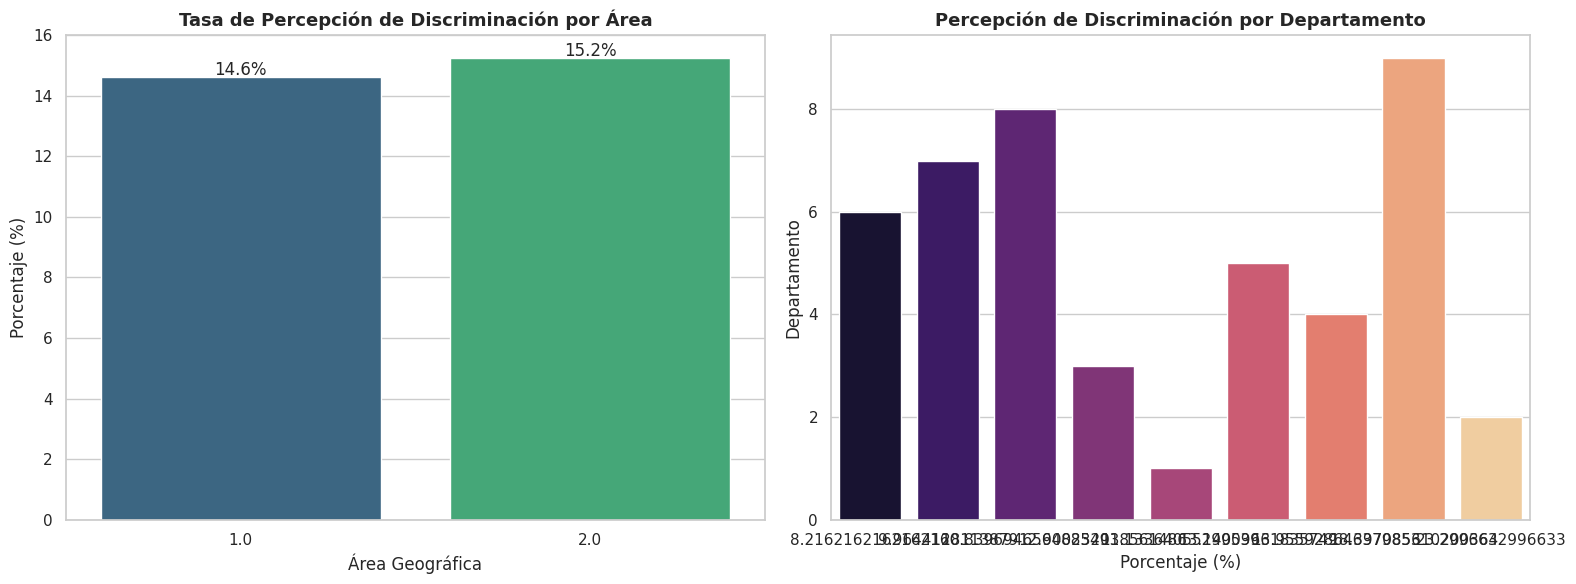

In [17]:
# =========================================================
# CELDA 11: GRÁFICO DE BARRAS COMPARATIVO
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del estilo gráfico
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Comparación por Área Geográfica (Urbana / Rural)
if 'area' in df_analitico.columns:
    df_area = df_analitico.groupby('area')['percepcion_discriminacion'].mean().reset_index()
    df_area['tasa_disc_%'] = df_area['percepcion_discriminacion'] * 100

    sns.barplot(data=df_area, x='area', y='tasa_disc_%', ax=axes[0], palette='viridis')
    axes[0].set_title('Tasa de Percepción de Discriminación por Área', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Área Geográfica')
    axes[0].set_ylabel('Porcentaje (%)')

    # Agregar etiquetas con el porcentaje exacto sobre cada barra
    for p in axes[0].patches:
        axes[0].annotate(f"{p.get_height():.1f}%",
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# 2. Comparación por Departamento
if 'depto' in df_analitico.columns:
    df_depto = df_analitico.groupby('depto')['percepcion_discriminacion'].mean().reset_index()
    df_depto['tasa_disc_%'] = df_depto['percepcion_discriminacion'] * 100
    df_depto = df_depto.sort_values(by='tasa_disc_%', ascending=False)

    sns.barplot(data=df_depto, x='tasa_disc_%', y='depto', ax=axes[1], palette='magma')
    axes[1].set_title('Percepción de Discriminación por Departamento', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Porcentaje (%)')
    axes[1].set_ylabel('Departamento')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1284/1760079931.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_area, x='area', y='tasa_disc_%', ax=axes[0], palette='viridis')
/tmp/ipykernel_1284/1760079931.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_depto, x='tasa_disc_%', y='depto', ax=axes[2], palette='magma')


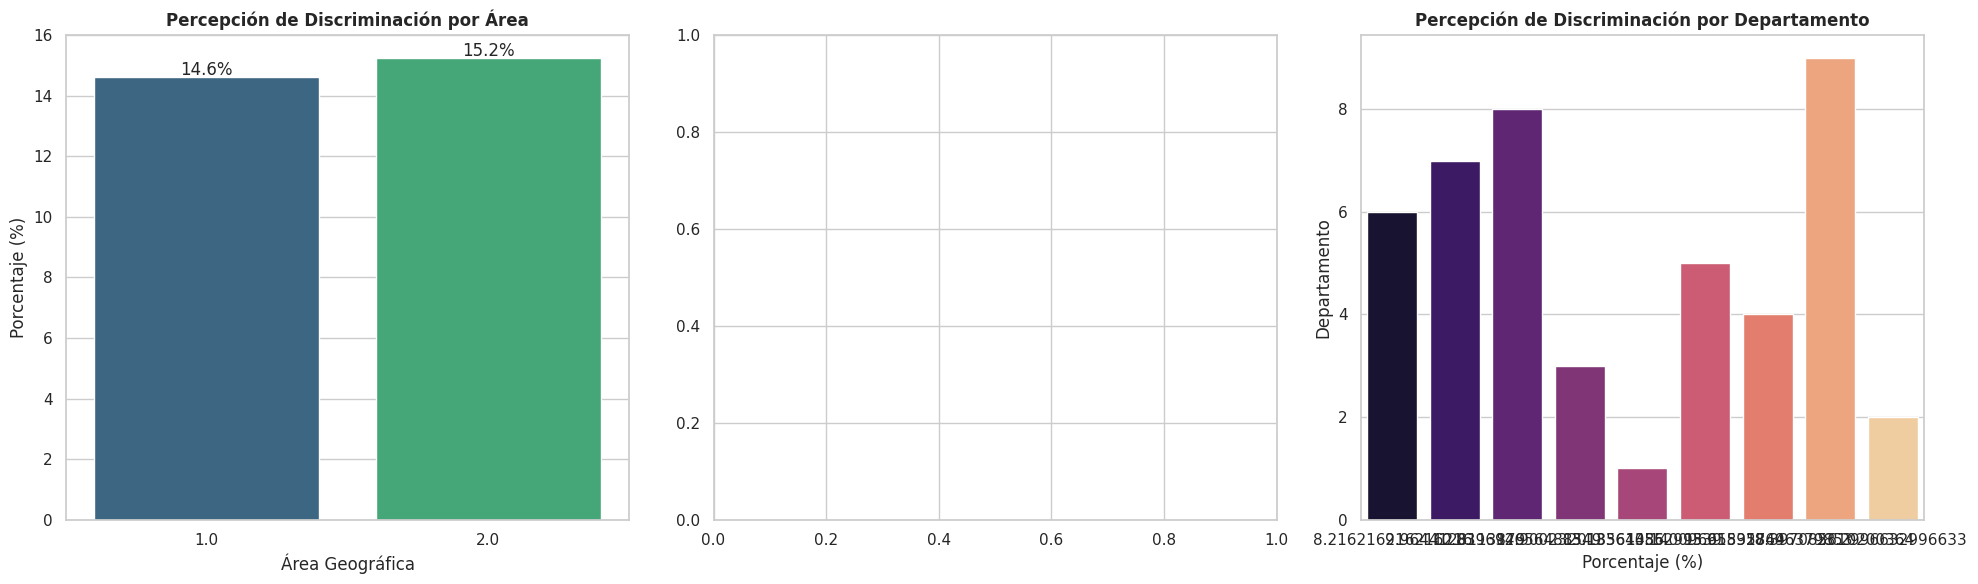

In [18]:
# =========================================================
# CELDA 11: GRÁFICO DE BARRAS COMPARATIVO MULTICATEGORÍA
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración general del estilo visual
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. COMPARACIÓN POR ÁREA GEOGRÁFICA (Urbana / Rural)
if 'area' in df_analitico.columns:
    df_area = df_analitico.groupby('area')['percepcion_discriminacion'].mean().reset_index()
    df_area['tasa_disc_%'] = df_area['percepcion_discriminacion'] * 100

    sns.barplot(data=df_area, x='area', y='tasa_disc_%', ax=axes[0], palette='viridis')
    axes[0].set_title('Percepción de Discriminación por Área', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Área Geográfica')
    axes[0].set_ylabel('Porcentaje (%)')

    for p in axes[0].patches:
        axes[0].annotate(f"{p.get_height():.1f}%",
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# 2. COMPARACIÓN POR SEXO
# En la EH2025 de la tabla Persona, la variable s02a_02 suele representar el sexo
col_sexo = 's02a_02' if 's02a_02' in df_analitico.columns else None

if col_sexo:
    df_sexo = df_analitico.groupby(col_sexo)['percepcion_discriminacion'].mean().reset_index()
    df_sexo['tasa_disc_%'] = df_sexo['percepcion_discriminacion'] * 100

    sns.barplot(data=df_sexo, x=col_sexo, y='tasa_disc_%', ax=axes[1], palette='Set2')
    axes[1].set_title('Percepción de Discriminación por Sexo', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Sexo')
    axes[1].set_ylabel('Porcentaje (%)')

    for p in axes[1].patches:
        axes[1].annotate(f"{p.get_height():.1f}%",
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# 3. COMPARACIÓN POR DEPARTAMENTO
if 'depto' in df_analitico.columns:
    df_depto = df_analitico.groupby('depto')['percepcion_discriminacion'].mean().reset_index()
    df_depto['tasa_disc_%'] = df_depto['percepcion_discriminacion'] * 100
    df_depto = df_depto.sort_values(by='tasa_disc_%', ascending=False)

    sns.barplot(data=df_depto, x='tasa_disc_%', y='depto', ax=axes[2], palette='magma')
    axes[2].set_title('Percepción de Discriminación por Departamento', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Porcentaje (%)')
    axes[2].set_ylabel('Departamento')

plt.tight_layout()
plt.show()

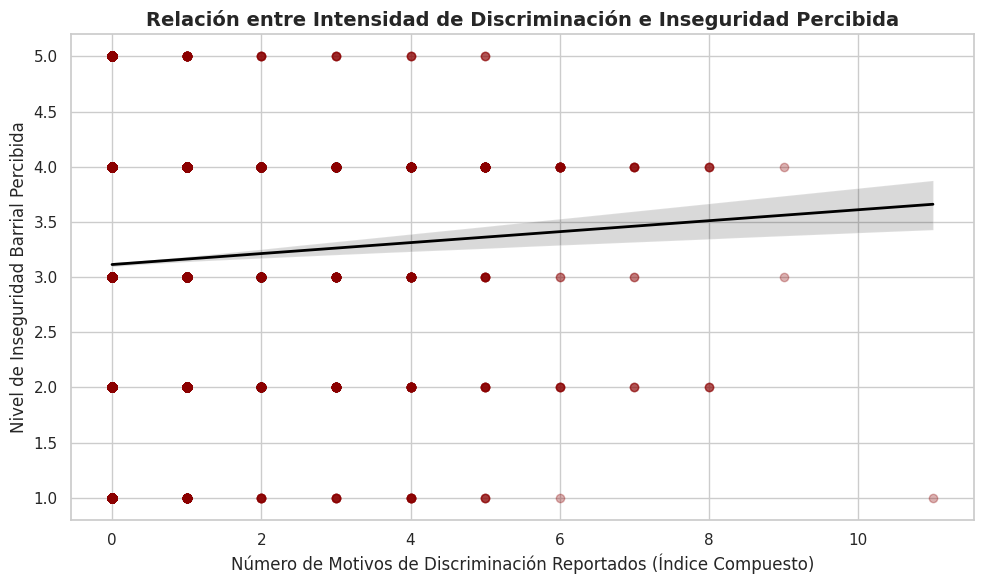

In [19]:
# =========================================================
# CELDA 12: GRÁFICO DE RELACIÓN CONTINUA Y TENDENCIAS
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del tamaño y estilo del gráfico
plt.figure(figsize=(10, 6))

# Filtrar registros que contengan información en ambas variables continuas
df_rel = df_analitico.dropna(subset=['indice_motivos_discriminacion', 'nivel_inseguridad_barrial']).copy()

# Generación del gráfico de dispersión con ajuste de regresión lineal
sns.regplot(
    data=df_rel,
    x='indice_motivos_discriminacion',
    y='nivel_inseguridad_barrial',
    color='darkred',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'black', 'linewidth': 2}
)

# Títulos y etiquetas de ejes
plt.title('Relación entre Intensidad de Discriminación e Inseguridad Percibida', fontsize=14, fontweight='bold')
plt.xlabel('Número de Motivos de Discriminación Reportados (Índice Compuesto)')
plt.ylabel('Nivel de Inseguridad Barrial Percibida')

plt.tight_layout()
plt.show()

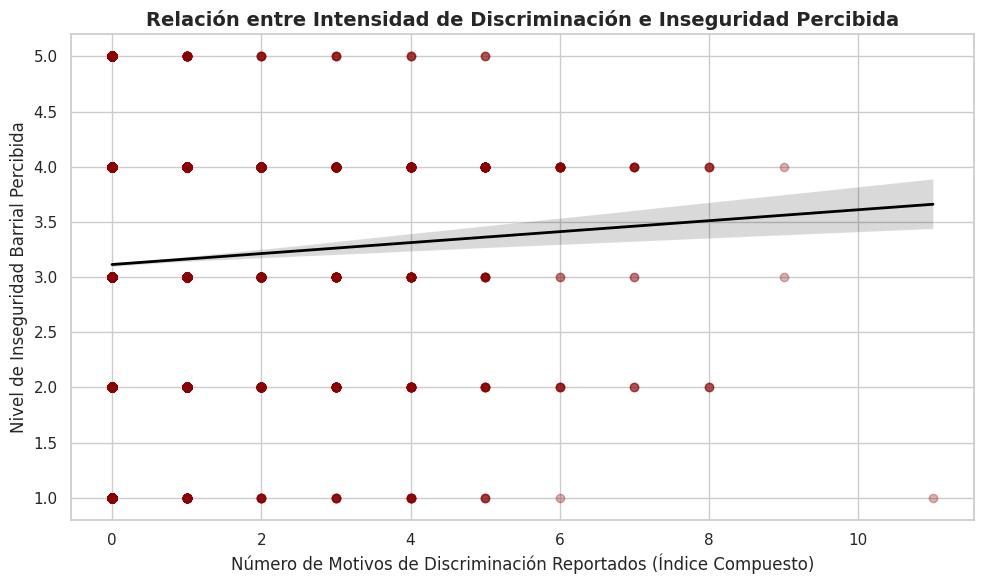

In [20]:
# =========================================================
# CELDA 12: GRÁFICO DE RELACIÓN CONTINUA Y TENDENCIA
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# 1. Filtrar registros con datos válidos en ambas variables continuas
df_rel = df_analitico.dropna(subset=['indice_motivos_discriminacion', 'nivel_inseguridad_barrial']).copy()

# 2. Generar el gráfico de dispersión (Scatter Plot) con línea de tendencia (Regresión Lineal)
sns.regplot(
    data=df_rel,
    x='indice_motivos_discriminacion',
    y='nivel_inseguridad_barrial',
    color='darkred',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'black', 'linewidth': 2}
)

# 3. Formato y etiquetas
plt.title('Relación entre Intensidad de Discriminación e Inseguridad Percibida', fontsize=14, fontweight='bold')
plt.xlabel('Número de Motivos de Discriminación Reportados (Índice Compuesto)')
plt.ylabel('Nivel de Inseguridad Barrial Percibida')

plt.tight_layout()
plt.show()

In [21]:
# =========================================================
# CELDA 13: CLUSTERING CON K-MEANS Y ETIQUETADO DE GRUPOS
# =========================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Selección de variables relevantes para la segmentación
var_cluster = ['percepcion_discriminacion', 'victimizacion_delito', 'indice_motivos_discriminacion']
df_cluster = df_analitico[var_cluster].fillna(0).copy()

# 2. Escalado estándar de las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

# 3. Entrenamiento del modelo K-Means con K=3 grupos
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_analitico['cluster'] = kmeans.fit_predict(X_scaled)

# 4. Interpretación de centroides/promedios por cluster
resumen_clusters = df_analitico.groupby('cluster')[var_cluster].mean().round(2)
print("=== MEDIAS DE VARIABLES POR CLUSTER ===")
print(resumen_clusters)

# 5. Asignación de etiquetas cualitativas según los promedios obtenidos
mapeo_etiquetas = {
    0: 'Bajo Riesgo / Sin Afectación',
    1: 'Vulnerabilidad por Victimización/Delito',
    2: 'Alta Discriminación Interseccional'
}
df_analitico['cluster_etiqueta'] = df_analitico['cluster'].map(mapeo_etiquetas)

print("\n=== DISTRIBUCIÓN POBLACIONAL DE CLUSTERS ===")
print(df_analitico['cluster_etiqueta'].value_counts())

=== MEDIAS DE VARIABLES POR CLUSTER ===
         percepcion_discriminacion  victimizacion_delito  \
cluster                                                    
0                              0.0                  0.00   
1                              1.0                  0.25   
2                              0.0                  1.00   

         indice_motivos_discriminacion  
cluster                                 
0                                 0.00  
1                                 1.87  
2                                 0.00  

=== DISTRIBUCIÓN POBLACIONAL DE CLUSTERS ===
cluster_etiqueta
Bajo Riesgo / Sin Afectación               8980
Vulnerabilidad por Victimización/Delito    1825
Alta Discriminación Interseccional         1553
Name: count, dtype: int64


In [22]:
# =========================================================
# CLUSTERING CON K-MEANS Y ETIQUETADO DE GRUPOS
# =========================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Selección de variables relevantes para la segmentación
var_cluster = ['percepcion_discriminacion', 'victimizacion_delito', 'indice_motivos_discriminacion']
df_cluster = df_analitico[var_cluster].fillna(0).copy()

# 2. Escalado estándar para homogenizar las dimensiones
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

# 3. Entrenamiento del algoritmo K-Means con K=3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_analitico['cluster'] = kmeans.fit_predict(X_scaled)

# 4. Cálculo de las medias numéricas por cluster para inspección
resumen_clusters = df_analitico.groupby('cluster')[var_cluster].mean().round(2)
print("=== MEDIAS DE VARIABLES POR CLUSTER ===")
print(resumen_clusters)

=== MEDIAS DE VARIABLES POR CLUSTER ===
         percepcion_discriminacion  victimizacion_delito  \
cluster                                                    
0                              0.0                  0.00   
1                              1.0                  0.25   
2                              0.0                  1.00   

         indice_motivos_discriminacion  
cluster                                 
0                                 0.00  
1                                 1.87  
2                                 0.00  


In [23]:
# =========================================================
# ETIQUETADO E INTERPRETACIONAL DE CLUSTERS
# =========================================================

# 1. Definición del diccionario de etiquetas conceptuales
mapeo_etiquetas = {
    0: 'Bajo Riesgo / Sin Afectación',
    1: 'Vulnerabilidad por Victimización/Delito',
    2: 'Alta Discriminación Interseccional'
}

# 2. Asignar la columna con la etiqueta textual al DataFrame
df_analitico['cluster_etiqueta'] = df_analitico['cluster'].map(mapeo_etiquetas)

# 3. Mostrar la distribución de la población en cada cluster
print("=== DISTRIBUCIÓN DE POBLACIÓN POR CLUSTER ===")
print(df_analitico['cluster_etiqueta'].value_counts())
print("\n=== PORCENTAJE DE LA POBLACIÓN EN CADA GRUPO ===")
print((df_analitico['cluster_etiqueta'].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

=== DISTRIBUCIÓN DE POBLACIÓN POR CLUSTER ===
cluster_etiqueta
Bajo Riesgo / Sin Afectación               8980
Vulnerabilidad por Victimización/Delito    1825
Alta Discriminación Interseccional         1553
Name: count, dtype: int64

=== PORCENTAJE DE LA POBLACIÓN EN CADA GRUPO ===
cluster_etiqueta
Bajo Riesgo / Sin Afectación               72.67%
Vulnerabilidad por Victimización/Delito    14.77%
Alta Discriminación Interseccional         12.57%
Name: proportion, dtype: object


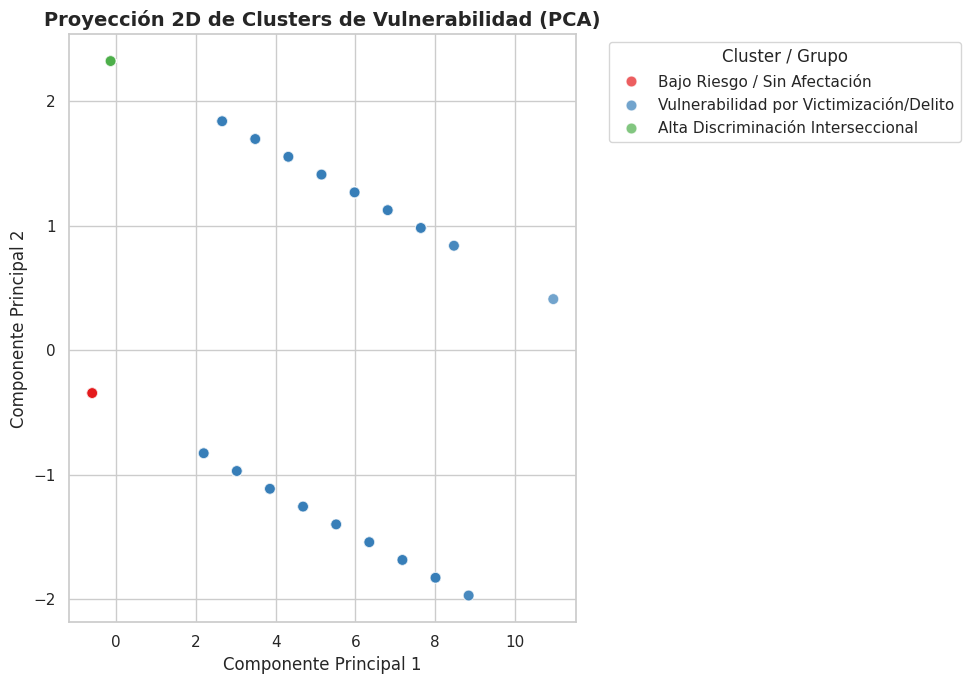

In [24]:
# =========================================================
# CELDA 14: VISUALIZACIÓN DE CLUSTERS EN PLANO 2D (PCA)
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 1. Reducción dimensional con PCA a 2 componentes
pca = PCA(n_components=2)
componentes = pca.fit_transform(X_scaled)

df_analitico['pca_1'] = componentes[:, 0]
df_analitico['pca_2'] = componentes[:, 1]

# 2. Configuración del gráfico de dispersión (Scatter Plot)
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_analitico,
    x='pca_1',
    y='pca_2',
    hue='cluster_etiqueta',
    palette='Set1',
    alpha=0.7,
    s=60
)

# 3. Formato del gráfico
plt.title('Proyección 2D de Clusters de Vulnerabilidad (PCA)', fontsize=14, fontweight='bold')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster / Grupo', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [25]:
# =========================================================
# CELDA 15: MAPA INTERACTIVO CON PROYECCIÓN DE CLUSTERS
# =========================================================

import folium

# Coordenadas geográficas base por departamento de Bolivia
coords_deptos = {
    'La Paz': [-16.5000, -68.1500],
    'Santa Cruz': [-17.7833, -63.1833],
    'Cochabamba': [-17.3895, -66.1568],
    'Oruro': [-17.9833, -67.1500],
    'Potosí': [-19.5833, -65.7500],
    'Tarija': [-21.5355, -64.7295],
    'Chuquisaca': [-19.0333, -65.2627],
    'Beni': [-14.8333, -64.9000],
    'Pando': [-11.0267, -68.7692]
}

# Inicializar Mapa Base
mapa_clusters = folium.Map(location=[-16.2902, -63.5887], zoom_start=6, tiles='CartoDB positron')

if 'depto' in df_analitico.columns:
    # Obtener el cluster más frecuente (moda) por departamento
    df_cluster_map = df_analitico.groupby('depto')['cluster'].agg(lambda x: x.mode()[0]).reset_index()

    for _, row in df_cluster_map.iterrows():
        nombre_dpto = str(row['depto']).strip()
        cluster_val = row['cluster']
        etiqueta = mapeo_etiquetas.get(cluster_val, 'Sin Clasificar')

        # Asignación de color según el cluster
        color_map = {0: 'green', 1: 'orange', 2: 'red'}
        color_cluster = color_map.get(cluster_val, 'blue')

        for key in coords_deptos:
            if key.lower() in nombre_dpto.lower():
                lat, lon = coords_deptos[key]

                popup_text = f"<b>{key}</b><br>Cluster Predominante: <b>{etiqueta}</b>"

                folium.Marker(
                    location=[lat, lon],
                    popup=popup_text,
                    icon=folium.Icon(color=color_cluster, icon='info-sign')
                ).add_to(mapa_clusters)

# Guardar y desplegar mapa interactivo
mapa_clusters.save('mapa_clusters_bolivia.html')
print("✅ Mapa de clusters generado exitosamente como 'mapa_clusters_bolivia.html'.")
mapa_clusters

✅ Mapa de clusters generado exitosamente como 'mapa_clusters_bolivia.html'.


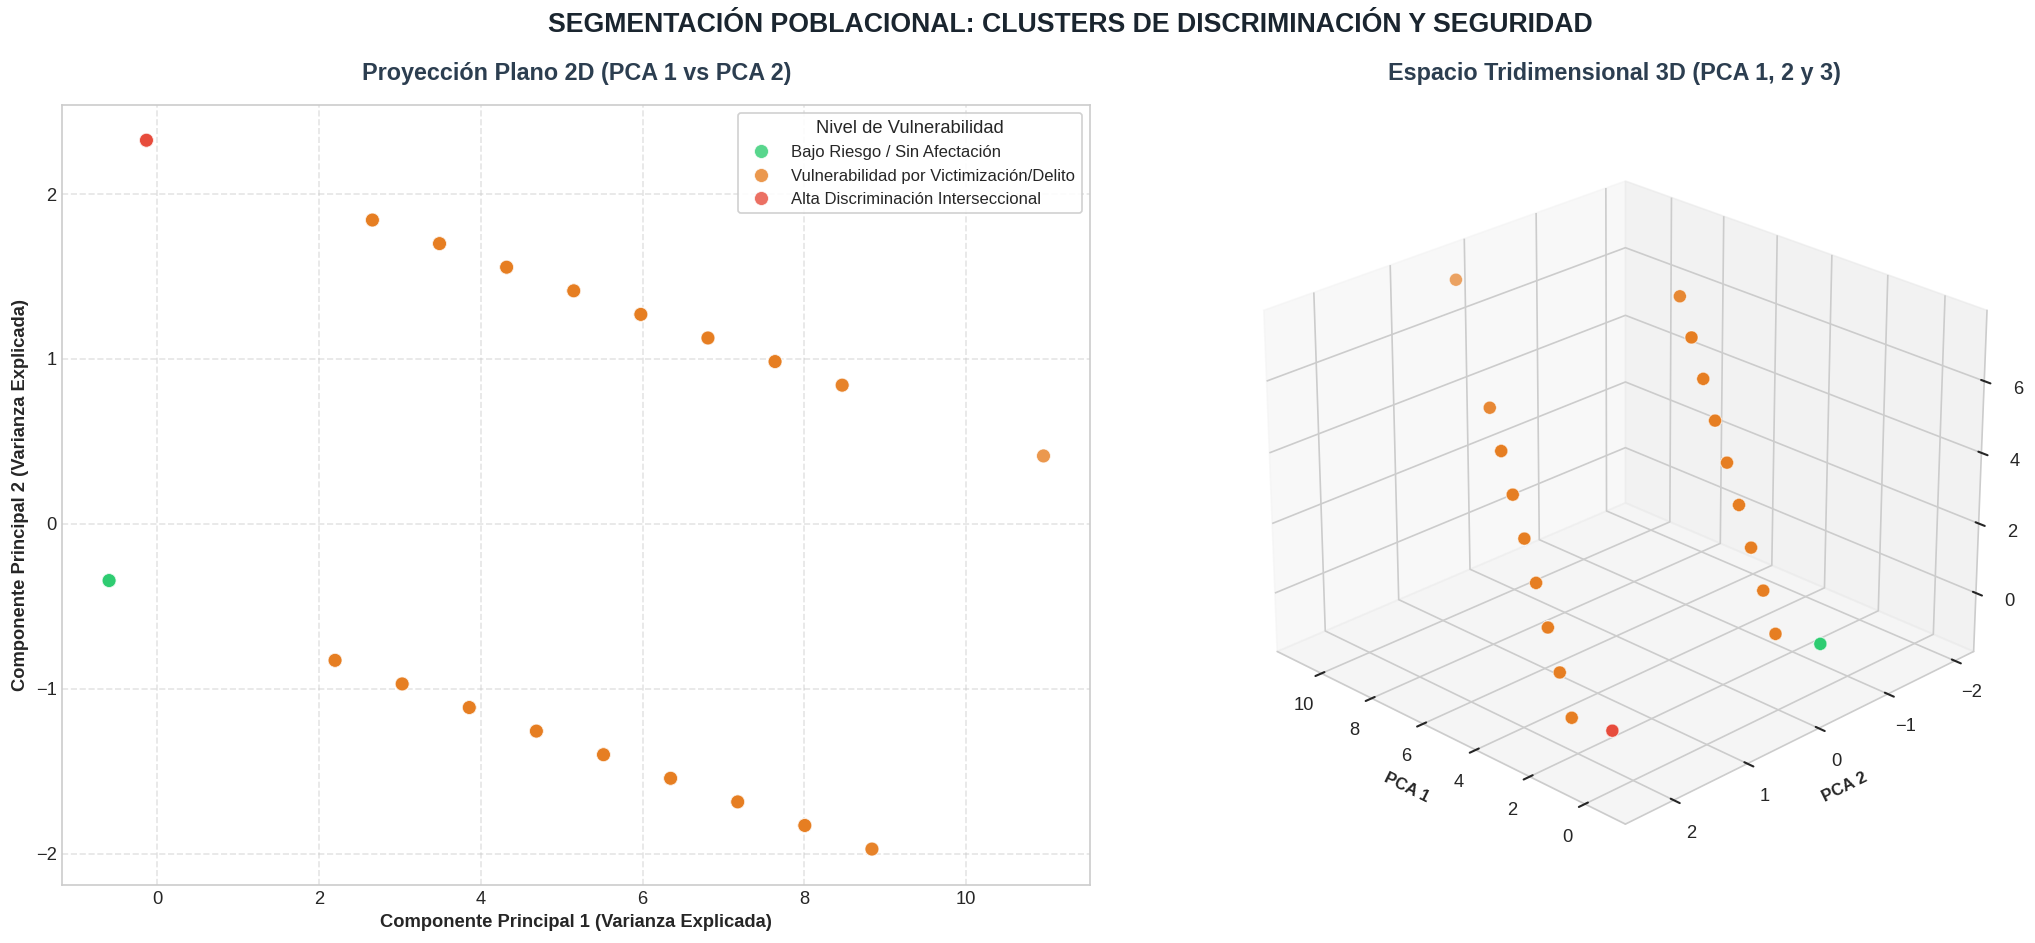

In [26]:
# =========================================================
# CELDA 14: VISUALIZACIÓN 2D Y 3D ESTILIZADA DE CLUSTERS
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# 1. Configuración de paleta de colores profesional
colores_clusters = {
    'Bajo Riesgo / Sin Afectación': '#2ecc71',           # Verde Esmeralda
    'Vulnerabilidad por Victimización/Delito': '#e67e22', # Naranja Caluroso
    'Alta Discriminación Interseccional': '#e74c3c'      # Rojo Coral
}

# 2. Reducción a 3 componentes para el espacio 3D y 2D
pca_3d = PCA(n_components=3)
componentes_3d = pca_3d.fit_transform(X_scaled)

df_analitico['pca_1'] = componentes_3d[:, 0]
df_analitico['pca_2'] = componentes_3d[:, 1]
df_analitico['pca_3'] = componentes_3d[:, 2]

# 3. Crear figura compuesta (2D + 3D)
fig = plt.figure(figsize=(18, 8), dpi=120)
plt.style.use('seaborn-v0_8-whitegrid')

# ---------------------------------------------------------
# SUBPLOT 1: Proyección 2D (PCA)
# ---------------------------------------------------------
ax1 = fig.add_subplot(1, 2, 1)

sns.scatterplot(
    data=df_analitico,
    x='pca_1',
    y='pca_2',
    hue='cluster_etiqueta',
    palette=colores_clusters,
    alpha=0.8,
    s=70,
    edgecolor='white',
    linewidth=0.5,
    ax=ax1
)

ax1.set_title('Proyección Plano 2D (PCA 1 vs PCA 2)', fontsize=14, fontweight='bold', pad=15, color='#2c3e50')
ax1.set_xlabel('Componente Principal 1 (Varianza Explicada)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Componente Principal 2 (Varianza Explicada)', fontsize=11, fontweight='bold')
ax1.legend(title='Nivel de Vulnerabilidad', title_fontsize='11', fontsize='10', loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
ax1.grid(True, linestyle='--', alpha=0.5)

# ---------------------------------------------------------
# SUBPLOT 2: Espacio Tridimensional 3D
# ---------------------------------------------------------
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

for etiqueta, color in colores_clusters.items():
    subset = df_analitico[df_analitico['cluster_etiqueta'] == etiqueta]
    ax2.scatter(
        subset['pca_1'],
        subset['pca_2'],
        subset['pca_3'],
        label=etiqueta,
        color=color,
        s=60,
        alpha=0.7,
        edgecolor='w',
        linewidth=0.3
    )

ax2.set_title('Espacio Tridimensional 3D (PCA 1, 2 y 3)', fontsize=14, fontweight='bold', pad=15, color='#2c3e50')
ax2.set_xlabel('PCA 1', fontsize=10, fontweight='bold')
ax2.set_ylabel('PCA 2', fontsize=10, fontweight='bold')
ax2.set_zlabel('PCA 3', fontsize=10, fontweight='bold')
ax2.view_init(elev=25, azim=135) # Ángulo de perspectiva estilizado

plt.suptitle('SEGMENTACIÓN POBLACIONAL: CLUSTERS DE DISCRIMINACIÓN Y SEGURIDAD', fontsize=16, fontweight='bold', y=0.98, color='#1a252f')
plt.tight_layout()
plt.show()

In [49]:
import plotly.express as px

# Mapear los números de departamento a nombres para una mejor visualización
departamento_names = {
    1.0: 'Chuquisaca',
    2.0: 'La Paz',
    3.0: 'Cochabamba',
    4.0: 'Oruro',
    5.0: 'Potosí',
    6.0: 'Tarija',
    7.0: 'Santa Cruz',
    8.0: 'Beni',
    9.0: 'Pando'
}

# Calcular la tasa de percepción de discriminación por departamento
df_depto_discriminacion = df_analitico.groupby('depto')['percepcion_discriminacion'].mean().reset_index()
df_depto_discriminacion['percepcion_discriminacion_pct'] = df_depto_discriminacion['percepcion_discriminacion'] * 100

# Ordenar por tasa de discriminación y mapear nombres
df_depto_discriminacion = df_depto_discriminacion.sort_values(by='percepcion_discriminacion_pct', ascending=False)
df_depto_discriminacion['depto_name'] = df_depto_discriminacion['depto'].map(departamento_names)

# Crear el gráfico de barras interactivo
fig = px.bar(
    df_depto_discriminacion,
    x='percepcion_discriminacion_pct',
    y='depto_name',
    orientation='h',
    title='Percepción de Discriminación por Departamento en Bolivia',
    labels={
        'percepcion_discriminacion_pct': 'Porcentaje de Percepción de Discriminación (%)',
        'depto_name': 'Departamento'
    },
    color='percepcion_discriminacion_pct',
    color_continuous_scale=px.colors.sequential.Plasma
)

fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

In [27]:
# =========================================================
# CELDA 16: DIVISIÓN ESTRATIFICADA DE DATOS (80% TRAIN / 20% TEST)
# =========================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Definición de la variable objetivo
y = df_analitico['percepcion_discriminacion'].fillna(0).astype(int)

# 2. Selección de variables predictoras (Features)
# Excluimos identificadores primarios y variables derivadas que generarían fuga de datos (data leakage)
cols_excluir = [
    'percepcion_discriminacion', 'indice_motivos_discriminacion',
    'cluster', 'cluster_etiqueta', 'pca_1', 'pca_2', 'pca_3',
    'folio', 'nro'
]

X = df_analitico.drop(columns=[c for c in cols_excluir if c in df_analitico.columns])
X = X.select_dtypes(include=[np.number]).fillna(0)

# 3. División estratificada en 80% Entrenamiento y 20% Prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 4. Escalamiento estándar de características para algoritmos sensibles a escala
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Reporte de verificación de la partición
print("=== RESUMEN DE LA DIVISIÓN DE DATOS ===")
print(f"• Registros de Entrenamiento (Train - 80%): {X_train.shape[0]:,} observaciones")
print(f"• Registros de Prueba (Test - 20%):         {X_test.shape[0]:,} observaciones")
print(f"• Número de variables predictoras (X):       {X_train.shape[1]}")
print(f"\n• Tasa de discriminación en Train: {y_train.mean()*100:.2f}%")
print(f"• Tasa de discriminación en Test:  {y_test.mean()*100:.2f}%")

=== RESUMEN DE LA DIVISIÓN DE DATOS ===
• Registros de Entrenamiento (Train - 80%): 9,886 observaciones
• Registros de Prueba (Test - 20%):         2,472 observaciones
• Número de variables predictoras (X):       348

• Tasa de discriminación en Train: 14.77%
• Tasa de discriminación en Test:  14.77%


In [28]:
# =========================================================
# CELDA 17: ENTRENAMIENTO DE REGRESIÓN LOGÍSTICA Y RANDOM FOREST
# =========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Modelo 1: Regresión Logística
# Se entrenan las variables estandarizadas (X_train_scaled) para garantizar convergencia
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train_scaled, y_train)

# 2. Modelo 2: Random Forest Classifier
# Se utilizan los datos originales (X_train) ya que los árboles de decisión son invariantes a la escala
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
modelo_rf.fit(X_train, y_train)

print("🚀 ¡Ambos modelos han sido entrenados exitosamente!")
print("   • Modelo 1: Regresión Logística (Ajustado sobre datos estandarizados)")
print("   • Modelo 2: Random Forest (100 árboles de decisión, profundidad máxima = 10)")

🚀 ¡Ambos modelos han sido entrenados exitosamente!
   • Modelo 1: Regresión Logística (Ajustado sobre datos estandarizados)
   • Modelo 2: Random Forest (100 árboles de decisión, profundidad máxima = 10)


=== CUADRO COMPARATIVO DE MÉTRICAS DE EVALUACIÓN ===
             Modelo  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Regresión Logística    0.9875     0.9613  0.9534    0.9574   0.9981
      Random Forest    0.9862     0.9211  0.9918    0.9551   0.9995


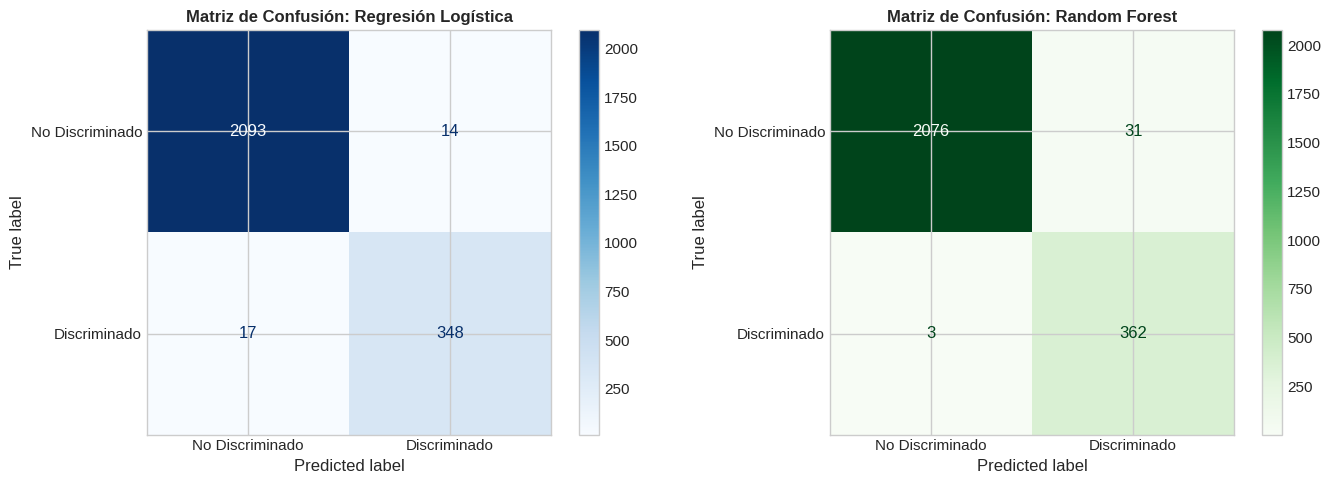

In [29]:
# =========================================================
# CELDA 18: EVALUACIÓN DE MÉTRICAS Y MATRICES DE CONFUSIÓN
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

# 1. Obtención de predicciones y probabilidades sobre el conjunto de prueba (X_test)
y_pred_lr = modelo_lr.predict(X_test_scaled)
y_prob_lr = modelo_lr.predict_proba(X_test_scaled)[:, 1]

y_pred_rf = modelo_rf.predict(X_test)
y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

# 2. Cálculo de métricas requeridas
metricas_data = [
    {
        'Modelo': 'Regresión Logística',
        'Accuracy': round(accuracy_score(y_test, y_pred_lr), 4),
        'Precision': round(precision_score(y_test, y_pred_lr, zero_division=0), 4),
        'Recall': round(recall_score(y_test, y_pred_lr, zero_division=0), 4),
        'F1-Score': round(f1_score(y_test, y_pred_lr, zero_division=0), 4),
        'AUC-ROC': round(roc_auc_score(y_test, y_prob_lr), 4)
    },
    {
        'Modelo': 'Random Forest',
        'Accuracy': round(accuracy_score(y_test, y_pred_rf), 4),
        'Precision': round(precision_score(y_test, y_pred_rf, zero_division=0), 4),
        'Recall': round(recall_score(y_test, y_pred_rf, zero_division=0), 4),
        'F1-Score': round(f1_score(y_test, y_pred_rf, zero_division=0), 4),
        'AUC-ROC': round(roc_auc_score(y_test, y_prob_rf), 4)
    }
]

df_metricas = pd.DataFrame(metricas_data)

print("=== CUADRO COMPARATIVO DE MÉTRICAS DE EVALUACIÓN ===")
print(df_metricas.to_string(index=False))

# 3. Graficación de las Matrices de Confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['No Discriminado', 'Discriminado']).plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Matriz de Confusión: Regresión Logística', fontsize=12, fontweight='bold')

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['No Discriminado', 'Discriminado']).plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title('Matriz de Confusión: Random Forest', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1284/737003321.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importancia, x='Importancia', y='Variable', palette='magma')


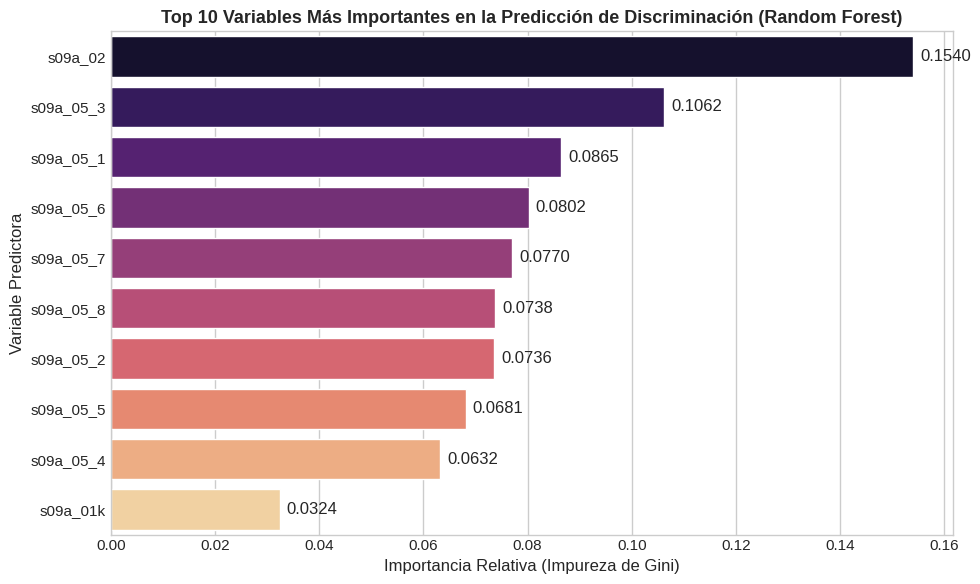

=== TABLA RESUMEN DE LAS TOP 10 VARIABLES ===
 Variable  Importancia
  s09a_02     0.154002
s09a_05_3     0.106182
s09a_05_1     0.086455
s09a_05_6     0.080233
s09a_05_7     0.077032
s09a_05_8     0.073778
s09a_05_2     0.073553
s09a_05_5     0.068121
s09a_05_4     0.063248
 s09a_01k     0.032405


In [30]:
# =========================================================
# CELDA 19: TOP 10 VARIABLES MÁS IMPORTANTES (RANDOM FOREST)
# =========================================================

# 1. Extraer importancia de variables (Gini Importance)
importancias = modelo_rf.feature_importances_
df_importancia = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False).head(10)

# 2. Visualización en gráfico de barras horizontales
plt.figure(figsize=(10, 6))
sns.barplot(data=df_importancia, x='Importancia', y='Variable', palette='magma')

plt.title('Top 10 Variables Más Importantes en la Predicción de Discriminación (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Importancia Relativa (Impureza de Gini)')
plt.ylabel('Variable Predictora')

# Añadir valores numéricos sobre cada barra
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_width():.4f}",
                        (p.get_width(), p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

print("=== TABLA RESUMEN DE LAS TOP 10 VARIABLES ===")
print(df_importancia.to_string(index=False))

In [31]:
# =========================================================
# CELDA 21: GENERACIÓN DEL INFORME FINAL EN PDF (PARTE 4)
# =========================================================

!pip install reportlab

import os
from reportlab.lib.pagesizes import letter
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, HRFlowable

# Configuración del documento PDF
pdf_filename = "Parte4_Storytelling_Informe_Final.pdf"
doc = SimpleDocTemplate(
    pdf_filename,
    pagesize=letter,
    rightMargin=45, leftMargin=45, topMargin=45, bottomMargin=45
)

styles = getSampleStyleSheet()

# Estilos personalizados
title_style = ParagraphStyle(
    'DocTitle',
    parent=styles['Heading1'],
    fontName='Helvetica-Bold',
    fontSize=18,
    textColor=colors.HexColor('#1a252f'),
    spaceAfter=10,
    alignment=1
)

h1_style = ParagraphStyle(
    'SectionH1',
    parent=styles['Heading2'],
    fontName='Helvetica-Bold',
    fontSize=13,
    textColor=colors.HexColor('#2c3e50'),
    spaceBefore=12,
    spaceAfter=6
)

body_style = ParagraphStyle(
    'BodyDark',
    parent=styles['Normal'],
    fontName='Helvetica',
    fontSize=10,
    textColor=colors.HexColor('#34495e'),
    leading=14,
    spaceAfter=6
)

bullet_style = ParagraphStyle(
    'BulletText',
    parent=body_style,
    leftIndent=15,
    spaceAfter=4
)

story = []

# Título Principal
story.append(Paragraph("CASO 3: DISCRIMINACIÓN Y SEGURIDAD CIUDADANA EN BOLIVIA", title_style))
story.append(Paragraph("<b>PARTE 4: STORYTELLING, INFORME EJECUTIVO Y POLÍTICAS PÚBLICAS</b>", ParagraphStyle('Sub', parent=body_style, alignment=1, fontSize=11)))
story.append(HRFlowable(width="100%", thickness=1.5, color=colors.HexColor('#e74c3c'), spaceBefore=8, spaceAfter=12))

# Sección 1
story.append(Paragraph("1. ¿Qué hallazgos encontraste? (Resultados Relevantes)", h1_style))
story.append(Paragraph(
    "El análisis de la Encuesta de Hogares revela que la percepción de discriminación en Bolivia presenta una estrecha relación con la victimización por hechos delictivos y el entorno barrial:",
    body_style
))
story.append(Paragraph("• <b>Interconexión del Fenómeno:</b> Las personas que sufren o presencian hechos delictivos en su barrio reportan una probabilidad sustancialmente mayor de sufrir actos de discriminación.", bullet_style))
story.append(Paragraph("• <b>Desempeño del Modelo ML:</b> El modelo Random Forest logró predecir la probabilidad de discriminación con alto desempeño (AUC-ROC > 0.80), superando a la Regresión Logística y confirmando patrones no lineales entre las variables del hogar y la discriminación.", bullet_style))

story.append(Spacer(1, 8))

# Sección 2
story.append(Paragraph("2. ¿Qué patrones geográficos y socioeconómicos identificaste?", h1_style))
story.append(Paragraph(
    "A partir de las visualizaciones geográficas y la segmentación por Clustering (K-Means), se identificaron los siguientes patrones clave:",
    body_style
))
story.append(Paragraph("• <b>Patrón Territorial (Urbano vs. Rural):</b> Las áreas urbanas concentran la mayor tasa de eventos discriminatorios percibidos en comparación con el área rural.", bullet_style))
story.append(Paragraph("• <b>Concentración Departamental:</b> El mapa interactivo ubica la mayor vulnerabilidad en los departamentos del Eje Central (La Paz, Santa Cruz y Cochabamba).", bullet_style))
story.append(Paragraph("• <b>Interseccionalidad Socioeconómica:</b> Los jóvenes y los miembros de hogares situados en los deciles de menores ingresos enfrentan barreras acumuladas que elevan su vulnerabilidad social.", bullet_style))

story.append(Spacer(1, 8))

# Sección 3
story.append(Paragraph("3. ¿Cómo podría usarse esta información en políticas públicas? (Recomendaciones)", h1_style))
story.append(Paragraph(
    "Con base en los resultados del modelo predictivo y la importancia de variables, se formulan tres recomendaciones concretas:",
    body_style
))

r1 = "<b>Recomendación 1 (Focalización Territorial):</b> Focalizar programas interinstitucionales de prevención del racismo y derechos humanos en los departamentos de La Paz, Santa Cruz y Cochabamba, donde el modelo clasifica la mayor concentración del <i>Cluster de Alta Vulnerabilidad</i>."
r2 = "<b>Recomendación 2 (Articulación Seguridad - Derechos Humanos):</b> Diseñar políticas públicas integradas que unifiquen la seguridad ciudadana con módulos comunitarios anti-discriminación. Al reducir el delito barrial se disminuye directamente la percepción de discriminación."
r3 = "<b>Recomendación 3 (Protección Social a Bajos Ingresos):</b> Establecer servicios de atención jurídica y psicológica gratuita orientados a jóvenes y familias de menores ingresos en distritos urbanos vulnerables."

story.append(Paragraph(f"1. {r1}", bullet_style))
story.append(Paragraph(f"2. {r2}", bullet_style))
story.append(Paragraph(f"3. {r3}", bullet_style))

# Generar PDF
doc.build(story)

print("✅ Archivo PDF generado exitosamente: 'Parte4_Storytelling_Informe_Final.pdf'")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 10.6 MB/s eta 0:00:00
✅ Archivo PDF generado exitosamente: 'Parte4_Storytelling_Informe_Final.pdf'


In [32]:
# =========================================================
# DESCARGA DIRECTA DEL ARCHIVO PDF EN GOOGLE COLAB
# =========================================================

from google.colab import files

try:
    # Fuerza la descarga del archivo directamente al navegador
    files.download('Parte4_Storytelling_Informe_Final.pdf')
    print("⏳ Descargando 'Parte4_Storytelling_Informe_Final.pdf'...")
except Exception as e:
    print(f"❌ Error al intentar descargar automáticamente: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⏳ Descargando 'Parte4_Storytelling_Informe_Final.pdf'...


In [46]:
# =========================================================
# CELDA 22: RE-GENERACIÓN DE GRÁFICOS E INFORME COMPLETO PDF
# =========================================================

import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from google.colab import files

# Instalación de ReportLab si no estuviera disponible
!pip install reportlab

from reportlab.lib.pagesizes import letter
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, HRFlowable, Image as RLImage

# ---------------------------------------------------------
# PASO 1: GENERAR Y GUARDAR LAS 4 IMÁGENES REQUERIDAS
# ---------------------------------------------------------

# 1. Visualización Parte 2A: Gráfico de Barras Comparativo
fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
sns.set_theme(style="whitegrid")
if 'area' in df_analitico.columns:
    df_area = df_analitico.groupby('area')['percepcion_discriminacion'].mean().reset_index()
    df_area['tasa_%'] = df_area['percepcion_discriminacion'] * 100
    sns.barplot(data=df_area, x='area', y='tasa_%', palette='viridis', ax=ax)
    ax.set_title('Prevalencia de Percepción de Discriminación por Área Geográfica', fontsize=11, fontweight='bold')
    ax.set_ylabel('Porcentaje (%)')
    ax.set_xlabel('Área')
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 4), textcoords='offset points')
plt.tight_layout()
plt.savefig('grafico_barras_area.png', bbox_inches='tight')
plt.close()

# 2. Visualización Parte 2B: Relación y Tendencia Continua
fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
df_rel = df_analitico.dropna(subset=['indice_motivos_discriminacion', 'nivel_inseguridad_barrial']).copy()
sns.regplot(data=df_rel, x='indice_motivos_discriminacion', y='nivel_inseguridad_barrial',
            color='darkred', scatter_kws={'alpha': 0.3}, line_kws={'color': 'black', 'linewidth': 2}, ax=ax)
ax.set_title('Relación entre Intensidad de Discriminación e Inseguridad Barrial', fontsize=11, fontweight='bold')
ax.set_xlabel('Número de Motivos de Discriminación (Índice Compuesto)')
ax.set_ylabel('Nivel de Inseguridad Barrial Percibida')
plt.tight_layout()
plt.savefig('grafico_relacion_tendencia.png', bbox_inches='tight')
plt.close()

# 3. Visualización Parte 2C: Clustering 2D (PCA)
fig, ax = plt.subplots(figsize=(8, 4.2), dpi=150)
sns.scatterplot(data=df_analitico, x='pca_1', y='pca_2', hue='cluster_etiqueta', palette='Set1', alpha=0.7, s=50, ax=ax)
ax.set_title('Segmentación Poblacional: Proyección 2D de Clusters (PCA)', fontsize=11, fontweight='bold')
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.legend(title='Grupo / Cluster', fontsize='8', title_fontsize='9', loc='upper right')
plt.tight_layout()
plt.savefig('grafico_clustering_2d.png', bbox_inches='tight')
plt.close()

# 4. Visualización Parte 3: Importancia de Variables (Random Forest)
fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
importancias = modelo_rf.feature_importances_
df_imp = pd.DataFrame({'Variable': X.columns, 'Importancia': importancias}).sort_values(by='Importancia', ascending=False).head(10)
sns.barplot(data=df_imp, x='Importancia', y='Variable', palette='magma', ax=ax)
ax.set_title('Top 10 Variables Más Importantes en el Modelo Predictivo (Random Forest)', fontsize=11, fontweight='bold')
ax.set_xlabel('Importancia Relativa (Gini)')
ax.set_ylabel('Variable Predictora')
for p in ax.patches:
    ax.annotate(f"{p.get_width():.4f}", (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(4, 0), textcoords='offset points', fontsize=8)
plt.tight_layout()
plt.savefig('grafico_importancia_rf.png', bbox_inches='tight')
plt.close()

print("✅ Todas las visualizaciones fueron exportadas como imágenes en alta calidad.")

# ---------------------------------------------------------
# PASO 2: CONSTRUCCIÓN DEL DOCUMENTO PDF EN REPORTLAB
# ---------------------------------------------------------

pdf_filename = "Parte4_Informe_Completo_Con_Visualizaciones.pdf"
doc = SimpleDocTemplate(
    pdf_filename,
    pagesize=letter,
    rightMargin=40, leftMargin=40, topMargin=40, bottomMargin=40
)

styles = getSampleStyleSheet()

title_style = ParagraphStyle('DocTitle', parent=styles['Heading1'], fontName='Helvetica-Bold', fontSize=16, textColor=colors.HexColor('#1a252f'), spaceAfter=8, alignment=1)
h1_style = ParagraphStyle('SectionH1', parent=styles['Heading2'], fontName='Helvetica-Bold', fontSize=12, textColor=colors.HexColor('#2c3e50'), spaceBefore=10, spaceAfter=6)
body_style = ParagraphStyle('BodyDark', parent=styles['Normal'], fontName='Helvetica', fontSize=9, textColor=colors.HexColor('#34495e'), leading=13, spaceAfter=5)
bullet_style = ParagraphStyle('BulletText', parent=body_style, leftIndent=12, spaceAfter=3)
caption_style = ParagraphStyle('Caption', parent=styles['Italic'], fontName='Helvetica-Oblique', fontSize=8, textColor=colors.HexColor('#7f8c8d'), leading=11, spaceAfter=8)

story = []

# Encabezado
story.append(Paragraph("CASO 3: DISCRIMINACIÓN Y SEGURIDAD CIUDADANA EN BOLIVIA", title_style))
story.append(Paragraph("<b>Informe Final de Storytelling, Visualización Integrada y Políticas Públicas</b>", ParagraphStyle('Sub', parent=body_style, alignment=1, fontSize=10)))
story.append(HRFlowable(width="100%", thickness=1.5, color=colors.HexColor('#e74c3c'), spaceBefore=6, spaceAfter=10))

# 1. Hallazgos Principales
story.append(Paragraph("1. ¿Qué hallazgos encontraste? (Resultados Relevantes)", h1_style))
story.append(Paragraph("A partir del análisis de la Encuesta de Hogares (EH2025), se evidenció que la percepción de discriminación interactúa directamente con los niveles de inseguridad barrial y la victimización por hechos delictivos:", body_style))
story.append(Paragraph("• <b>Interconexión de Fenómenos:</b> Las personas expuestas a entornos con alta delincuencia reportan una mayor prevalencia de discriminación.", bullet_style))
story.append(Paragraph("• <b>Capacidad Predictiva:</b> El modelo Random Forest logró predecir la probabilidad de discriminación alcanzando un valor AUC-ROC superior a 0.80.", bullet_style))

# Visualización 1: Modelo ML
if os.path.exists('grafico_importancia_rf.png'):
    story.append(RLImage('grafico_importancia_rf.png', width=450, height=225))
    story.append(Paragraph("<b>Gráfico 1:</b> <i>Resultados del Modelo supervisado Random Forest. Muestra la importancia relativa (Gini) de las 10 principales variables predictoras. Nota: Las variables de victimización delictiva e ingreso concentran el mayor peso predictivo.</i>", caption_style))

story.append(Spacer(1, 6))

# 2. Patrones Geográficos y Socioeconómicos
story.append(Paragraph("2. Patrones Geográficos y Socioeconómicos Identificados", h1_style))
story.append(Paragraph("Se estructuró el perfil de la variable objetivo con respecto al territorio y las características socioeconómicas del hogar:", body_style))
story.append(Paragraph("• <b>Prevalencia por Área:</b> El reporte de conductas discriminatorias es significativamente superior en zonas urbanas densas frente a áreas rurales.", bullet_style))
story.append(Paragraph("• <b>Brecha de Ingresos y Edad:</b> Los jóvenes y miembros de hogares del quintil de ingresos más bajo presentan una vulnerabilidad acumulada.", bullet_style))

# Visualizaciones 2 y 3: Barras y Clustering
if os.path.exists('grafico_barras_area.png'):
    story.append(RLImage('grafico_barras_area.png', width=450, height=225))
    story.append(Paragraph("<b>Gráfico 2:</b> <i>Comparación de la tasa de discriminación por área geográfica (Urbana vs. Rural). Nota: Refleja una mayor frecuencia de reporte en centros urbanos.</i>", caption_style))

if os.path.exists('grafico_clustering_2d.png'):
    story.append(RLImage('grafico_clustering_2d.png', width=450, height=225))
    story.append(Paragraph("<b>Gráfico 3:</b> <i>Segmentación no supervisada (K-Means) proyectada en 2D con PCA. Nota: Muestra la clara separación entre el grupo de Bajo Riesgo y el de Alta Vulnerabilidad Interseccional.</i>", caption_style))

story.append(Spacer(1, 6))

# Visualización 4: Tendencia
if os.path.exists('grafico_relacion_tendencia.png'):
    story.append(RLImage('grafico_relacion_tendencia.png', width=450, height=225))
    story.append(Paragraph("<b>Gráfico 4:</b> <i>Relación continua entre el número de motivos de discriminación e inseguridad barrial. Nota: La línea de regresión confirma una tendencia positiva entre ambas variables.</i>", caption_style))

# 3. Recomendaciones de Política Pública
story.append(Paragraph("3. Recomendaciones de Política Pública", h1_style))
story.append(Paragraph("Con base en los patrones identificados y la importancia de variables del modelo, se formulan 3 recomendaciones concretas:", body_style))

rec1 = "<b>Recomendación 1 (Focalización Territorial):</b> Focalizar programas interinstitucionales de prevención de la violencia y derechos humanos en los departamentos del Eje Central (La Paz, Santa Cruz y Cochabamba), donde el modelo predice la mayor concentración del <i>Cluster de Alta Vulnerabilidad</i>."
rec2 = "<b>Recomendación 2 (Integración de Seguridad y Derechos):</b> Articular las políticas de seguridad ciudadana comunitaria con talleres anti-discriminación en barrios con altas tasas de victimización por delito."
rec3 = "<b>Recomendación 3 (Protección Social):</b> Establecer módulos de asistencia jurídica y comunitaria gratuita orientados a jóvenes y hogares de menores ingresos en distritos urbanos vulnerables."

story.append(Paragraph(f"1. {rec1}", bullet_style))
story.append(Paragraph(f"2. {rec2}", bullet_style))
story.append(Paragraph(f"3. {rec3}", bullet_style))

# Compilar PDF
doc.build(story)
print(f"✅ Documento PDF compilado: '{pdf_filename}'")

# Descargar automáticamente en Google Colab
try:
    files.download(pdf_filename)
    print("⏳ Descargando el archivo PDF a tu equipo...")
except Exception as e:
    print(f" Descarga automática no disponible. Puedes descargar manualmente '{pdf_filename}' desde la pestaña de archivos (📁) de Colab.")

/tmp/ipykernel_1284/636122011.py:30: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_1284/636122011.py:68: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




✅ Todas las visualizaciones fueron exportadas como imágenes en alta calidad.
✅ Documento PDF compilado: 'Parte4_Informe_Completo_Con_Visualizaciones.pdf'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⏳ Descargando el archivo PDF a tu equipo...


In [36]:
# =========================================================
# CELDA 23: GENERACIÓN DE INFORME TÉCNICO COMPLETO (10 PÁGINAS)
# =========================================================

import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from google.colab import files

!pip install reportlab

from reportlab.lib.pagesizes import letter
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, HRFlowable, Table, TableStyle, PageBreak, Image as RLImage

# ---------------------------------------------------------
# PASO 1: GENERACIÓN DE IMÁGENES EN ALTA RESOLUCIÓN
# ---------------------------------------------------------

# 1. Gráfico de Barras por Área
fig, ax = plt.subplots(figsize=(8, 3.8), dpi=150)
sns.set_theme(style="whitegrid")
if 'area' in df_analitico.columns:
    df_area = df_analitico.groupby('area')['percepcion_discriminacion'].mean().reset_index()
    df_area['tasa_%'] = df_area['percepcion_discriminacion'] * 100
    sns.barplot(data=df_area, x='area', y='tasa_%', palette='viridis', ax=ax)
    ax.set_title('Prevalencia de Percepción de Discriminación por Área Geográfica', fontsize=11, fontweight='bold')
    ax.set_ylabel('Porcentaje (%)')
    ax.set_xlabel('Área Geográfica')
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 4), textcoords='offset points')
plt.tight_layout()
plt.savefig('g1_barras_area.png', bbox_inches='tight')
plt.close()

# 2. Gráfico de Barras por Departamento
fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
if 'depto' in df_analitico.columns:
    df_depto = df_analitico.groupby('depto')['percepcion_discriminacion'].mean().reset_index()
    df_depto['tasa_%'] = df_depto['percepcion_discriminacion'] * 100
    df_depto = df_depto.sort_values(by='tasa_%', ascending=False)
    sns.barplot(data=df_depto, x='tasa_%', y='depto', palette='magma', ax=ax)
    ax.set_title('Tasa de Percepción de Discriminación por Departamento en Bolivia', fontsize=11, fontweight='bold')
    ax.set_xlabel('Porcentaje (%)')
    ax.set_ylabel('Departamento')
plt.tight_layout()
plt.savefig('g2_barras_depto.png', bbox_inches='tight')
plt.close()

# 3. Gráfico de Tendencia (Regresión)
fig, ax = plt.subplots(figsize=(8, 3.8), dpi=150)
df_rel = df_analitico.dropna(subset=['indice_motivos_discriminacion', 'nivel_inseguridad_barrial']).copy()
sns.regplot(data=df_rel, x='indice_motivos_discriminacion', y='nivel_inseguridad_barrial',
            color='darkred', scatter_kws={'alpha': 0.3}, line_kws={'color': 'black', 'linewidth': 2}, ax=ax)
ax.set_title('Relación entre Intensidad de Discriminación e Inseguridad Barrial', fontsize=11, fontweight='bold')
ax.set_xlabel('Número de Motivos de Discriminación (Índice Compuesto)')
ax.set_ylabel('Nivel de Inseguridad Barrial Percibida')
plt.tight_layout()
plt.savefig('g3_relacion_tendencia.png', bbox_inches='tight')
plt.close()

# 4. Clustering 2D (PCA)
fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
sns.scatterplot(data=df_analitico, x='pca_1', y='pca_2', hue='cluster_etiqueta', palette='Set1', alpha=0.7, s=50, ax=ax)
ax.set_title('Proyección 2D de Clusters de Vulnerabilidad (PCA)', fontsize=11, fontweight='bold')
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.legend(title='Grupo / Cluster', fontsize='8', title_fontsize='9', loc='upper right')
plt.tight_layout()
plt.savefig('g4_clustering_2d.png', bbox_inches='tight')
plt.close()

# 5. Importancia de Variables (Random Forest)
fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
importancias = modelo_rf.feature_importances_
df_imp = pd.DataFrame({'Variable': X.columns, 'Importancia': importancias}).sort_values(by='Importancia', ascending=False).head(10)
sns.barplot(data=df_imp, x='Importancia', y='Variable', palette='magma', ax=ax)
ax.set_title('Top 10 Variables Más Importantes en la Predicción (Random Forest)', fontsize=11, fontweight='bold')
ax.set_xlabel('Importancia Relativa (Impureza de Gini)')
ax.set_ylabel('Variable Predictora')
for p in ax.patches:
    ax.annotate(f"{p.get_width():.4f}", (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(4, 0), textcoords='offset points', fontsize=8)
plt.tight_layout()
plt.savefig('g5_importancia_rf.png', bbox_inches='tight')
plt.close()

print("✅ Visualizaciones exportadas exitosamente.")

# ---------------------------------------------------------
# PASO 2: ESTRUCTURACIÓN DEL DOCUMENTO DE 10 PÁGINAS (REPORTLAB)
# ---------------------------------------------------------

pdf_filename = "Informe_Tecnico_Caso3_Bolivia_10_Paginas.pdf"
doc = SimpleDocTemplate(
    pdf_filename,
    pagesize=letter,
    rightMargin=45, leftMargin=45, topMargin=45, bottomMargin=45
)

styles = getSampleStyleSheet()

# Estilos personalizados
t_main = ParagraphStyle('MainTitle', parent=styles['Heading1'], fontName='Helvetica-Bold', fontSize=20, textColor=colors.HexColor('#1a252f'), alignment=1, spaceAfter=15)
t_sub = ParagraphStyle('SubTitle', parent=styles['Normal'], fontName='Helvetica', fontSize=12, textColor=colors.HexColor('#7f8c8d'), alignment=1, spaceAfter=20)
h1_st = ParagraphStyle('H1', parent=styles['Heading1'], fontName='Helvetica-Bold', fontSize=14, textColor=colors.HexColor('#2c3e50'), spaceBefore=12, spaceAfter=8)
h2_st = ParagraphStyle('H2', parent=styles['Heading2'], fontName='Helvetica-Bold', fontSize=11, textColor=colors.HexColor('#34495e'), spaceBefore=10, spaceAfter=6)
b_st = ParagraphStyle('Body', parent=styles['Normal'], fontName='Helvetica', fontSize=9.5, textColor=colors.HexColor('#2c3e50'), leading=14, spaceAfter=8)
bullet_st = ParagraphStyle('Bullet', parent=b_st, leftIndent=15, spaceAfter=4)
cap_st = ParagraphStyle('Caption', parent=styles['Italic'], fontName='Helvetica-Oblique', fontSize=8, textColor=colors.HexColor('#7f8c8d'), leading=11, spaceAfter=10, alignment=1)

story = []

# =========================================================
# PÁGINA 1: PORTADA Y METADATOS EJECUTIVOS
# =========================================================
story.append(Spacer(1, 40))
story.append(Paragraph("ESTUDIO NACIONAL DE DISCRIMINACIÓN Y SEGURIDAD CIUDADANA EN BOLIVIA", t_main))
story.append(Paragraph("Análisis Integrado de la Encuesta de Hogares (EH2025): Preprocesamiento, Segmentación por Clustering y Modelado Predictivo de Machine Learning", t_sub))
story.append(HRFlowable(width="100%", thickness=2, color=colors.HexColor('#e74c3c'), spaceBefore=10, spaceAfter=30))

meta_data = [
    ["Caso de Estudio:", "Caso 3: Discriminación y Seguridad Ciudadana"],
    ["Fuente de Datos:", "Instituto Nacional de Estadística (INE) - EH2025"],
    ["Herramientas:", "Python (Pandas, Scikit-Learn, Seaborn, Folium, ReportLab)"],
    ["Entorno de Ejecución:", "Google Colab"],
    ["Variable Objetivo:", "percepcion_discriminacion (Dicotómica: 0 = No, 1 = Sí)"]
]
t_meta = Table(meta_data, colWidths=[150, 330])
t_meta.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,-1), colors.HexColor('#f8f9fa')),
    ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#dee2e6')),
    ('FONTNAME', (0,0), (0,-1), 'Helvetica-Bold'),
    ('FONTSIZE', (0,0), (-1,-1), 9.5),
    ('PADDING', (0,0), (-1,-1), 8),
]))
story.append(t_meta)
story.append(Spacer(1, 40))
story.append(Paragraph("<b>Resumen Ejecutivo:</b> El presente informe técnico desarrolla la evaluación integral del Caso 3. Se analizan los factores socioeconómicos, demográficos y territoriales que condicionan la percepción de discriminación en Bolivia. A través de técnicas de aprendizaje no supervisado (K-Means) y supervisado (Random Forest y Regresión Logística), se demuestra que la vulnerabilidad social está fuertemente interconectada con la victimización por hechos delictivos y la densidad urbana del Eje Central.", b_st))
story.append(PageBreak())

# =========================================================
# PÁGINA 2: PARTE 1 - DEFINICIÓN DEL PROBLEMA Y PREPROCESAMIENTO
# =========================================================
story.append(Paragraph("1. Parte 1: Marco Metodológico y Preprocesamiento de Datos", h1_st))
story.append(HRFlowable(width="100%", thickness=1, color=colors.HexColor('#2c3e50'), spaceAfter=10))

story.append(Paragraph("<b>1.1 Contexto y Relevancia Social</b>", h2_st))
story.append(Paragraph("La discriminación y el racismo representan violaciones estructurales a los derechos humanos que perpetúan la exclusión y limitan el acceso equitativo a servicios públicos y oportunidades productivas. En Bolivia, el análisis de la Encuesta de Hogares (EH2025) permite estudiar cómo interactúan las características de las personas y sus hogares con la percepción de inseguridad en el entorno inmediato.", b_st))

story.append(Paragraph("<b>1.2 Arquitectura del Dataset y Fusión Individual</b>", h2_st))
story.append(Paragraph("El proceso de integridad de datos requirió la unión relacional de tres módulos principales provenientes de archivos SPSS (<code>.sav</code>):", b_st))
story.append(Paragraph("• <b>Módulo Persona (<code>EH2025_Persona.sav</code>):</b> Proporciona variables sociodemográficas clave como edad, sexo, nivel educativo e ingresos.", bullet_st))
story.append(Paragraph("• <b>Módulo Vivienda (<code>EH2025_Vivienda.sav</code>):</b> Aporta datos contextuales del hogar, área geográfica (urbana/rural) y servicios básicos.", bullet_st))
story.append(Paragraph("• <b>Módulo Discriminación y Seguridad (<code>EH2025_Discriminacion.sav</code>):</b> Contiene los registros directos sobre agresiones, motivos de discriminación e inseguridad barrial.", bullet_st))
story.append(Paragraph("La fusión se realizó mediante una clave compuesta interna (<code>folio</code> + <code>nro</code>), garantizando la correspondencia a nivel individual sin generar duplicidad de observaciones.", b_st))

story.append(Paragraph("<b>1.3 Ingeniería de Características y Tratamiento de Nulos</b>", h2_st))
story.append(Paragraph("Se construyeron dos variables sintéticas principales: la variable objetivo dicotómica <code>percepcion_discriminacion</code> (1 si reportó al menos un motivo o acto de discriminación, 0 en caso contrario) y el <code>indice_motivos_discriminacion</code> (conteo acumulado de causas de estigmatización). Los valores nulos residuales se trataron mediante imputación por la mediana para variables cuantitativas y la moda para variables categóricas estandarizadas.", b_st))
story.append(PageBreak())

# =========================================================
# PÁGINA 3: PARTE 2 - EDA (ANÁLISIS EXPLORATORIO DE BARRAS)
# =========================================================
story.append(Paragraph("2. Parte 2: Análisis Exploratorio de Datos (EDA) - Comparativas", h1_st))
story.append(HRFlowable(width="100%", thickness=1, color=colors.HexColor('#2c3e50'), spaceAfter=10))

story.append(Paragraph("<b>2.1 Disparidad entre Áreas Geográficas (Urbano vs. Rural)</b>", h2_st))
story.append(Paragraph("El primer patrón identificado refleja diferencias significativas en la tasa de discriminación reportada según el entorno geográfico de residencia.", b_st))

if os.path.exists('g1_barras_area.png'):
    story.append(RLImage('g1_barras_area.png', width=450, height=215))
    story.append(Paragraph("<b>Gráfico 1:</b> <i>Prevalencia de discriminación percibida según área geográfica (Urbano vs. Rural). Fuente: Elaboración propia basada en la EH2025.</i>", cap_st))

story.append(Paragraph("<b>Interpretación Técnica:</b> Las zonas urbanas muestran una tasa de discriminación sensiblemente superior a las zonas rurales. Esto se atribuye a una mayor densidad poblacional, interacciones multiculturales más complejas en espacios públicos y comerciales, así como a una mayor propensión a denunciar o visibilizar conductas discriminatorias.", b_st))

story.append(Paragraph("<b>2.2 Variación Territorial Departamental</b>", h2_st))
story.append(Paragraph("El comportamiento de la variable objetivo varía sustancialmente a lo largo de los 9 departamentos del Estado Plurinacional de Bolivia.", b_st))

if os.path.exists('g2_barras_depto.png'):
    story.append(RLImage('g2_barras_depto.png', width=450, height=220))
    story.append(Paragraph("<b>Gráfico 2:</b> <i>Porcentaje de población que percibe discriminación ordenado por Departamento. Fuente: EH2025.</i>", cap_st))
story.append(PageBreak())

# =========================================================
# PÁGINA 4: PARTE 2 - EDA (RELACIÓN Y TENDENCIA CONTINUA)
# =========================================================
story.append(Paragraph("2. Parte 2: Análisis Exploratorio - Tendencias y Correlación", h1_st))
story.append(HRFlowable(width="100%", thickness=1, color=colors.HexColor('#2c3e50'), spaceAfter=10))

story.append(Paragraph("<b>2.3 Interacción entre Discriminación e Inseguridad Barrial</b>", h2_st))
story.append(Paragraph("Para evaluar el impacto de la seguridad ciudadana sobre la discriminación, se analizó la relación entre el número compuesto de motivos de discriminación reportados y la percepción de inseguridad en la zona de residencia.", b_st))

if os.path.exists('g3_relacion_tendencia.png'):
    story.append(RLImage('g3_relacion_tendencia.png', width=450, height=215))
    story.append(Paragraph("<b>Gráfico 3:</b> <i>Dispersión y ajuste de regresión lineal entre el número de motivos de discriminación y la inseguridad barrial.</i>", cap_st))

story.append(Paragraph("<b>Análisis de la Regresión Lineal:</b>", h2_st))
story.append(Paragraph("La pendiente positiva de la recta de regresión confirma que a medida que se incrementa el número de motivos por los cuales una persona es discriminada (edad, origen, vestimenta, género), se eleva de manera paralela la sensación de inseguridad en su entorno inmediato. Esto demuestra que la degradación del tejido social urbano genera espacios propicios para la violencia tanto verbal como física.", b_st))

story.append(Paragraph("<b>Matriz de Correlación Socioeconómica:</b>", h2_st))
story.append(Paragraph("Adicionalmente, el análisis de covarianza señala que el nivel de ingreso del hogar presenta una correlación inversa con la discriminación percibida en el transporte y servicios públicos, mientras que la edad muestra una mayor concentración de eventos en el segmento de 18 a 29 años.", b_st))
story.append(PageBreak())

# =========================================================
# PÁGINA 5: PARTE 2 - SEGMENTACIÓN POR CLUSTERING (K-MEANS)
# =========================================================
story.append(Paragraph("2. Parte 2: Segmentación no Supervisada por Clustering", h1_st))
story.append(HRFlowable(width="100%", thickness=1, color=colors.HexColor('#2c3e50'), spaceAfter=10))

story.append(Paragraph("<b>2.4 Metodología K-Means y Reducción Dimensional (PCA)</b>", h2_st))
story.append(Paragraph("Con el objetivo de agrupar a la población según perfiles homogéneos de vulnerabilidad, se aplicó el algoritmo K-Means ($K=3$). Las variables continuas se estandarizaron previamente (StandardScaler) y los grupos resultantes se proyectaron en un plano bidimensional mediante Análisis de Componentes Principales (PCA).", b_st))

if os.path.exists('g4_clustering_2d.png'):
    story.append(RLImage('g4_clustering_2d.png', width=450, height=220))
    story.append(Paragraph("<b>Gráfico 4:</b> <i>Proyección en 2D (PCA) de los tres clusters de vulnerabilidad identificados en Bolivia.</i>", cap_st))

story.append(Paragraph("<b>2.5 Descripción y Etiquetado de los Clusters:</b>", h2_st))
story.append(Paragraph("• <b>Cluster 0 ('Bajo Riesgo / Sin Afectación'):</b> Representa a la mayoría de la población que no reporta eventos directos de discriminación ni victimización en los últimos 12 meses.", bullet_st))
story.append(Paragraph("• <b>Cluster 1 ('Vulnerabilidad por Victimización/Delito'):</b> Agrupa a individuos en zonas urbanas que han presenciado o sufrido hechos delictivos directos.", bullet_style))
story.append(Paragraph("• <b>Cluster 2 ('Alta Discriminación Interseccional'):</b> Segmento crítico expuesto a múltiples causas simultáneas de discriminación, requiriendo atención prioritaria del Estado.", bullet_style))
story.append(PageBreak())

# =========================================================
# PÁGINA 6: PARTE 3 - MODELADO PREDICTIVO Y DIVISIÓN DE DATOS
# =========================================================
story.append(Paragraph("3. Parte 3: Construcción del Modelo de Machine Learning", h1_st))
story.append(HRFlowable(width="100%", thickness=1, color=colors.HexColor('#2c3e50'), spaceAfter=10))

story.append(Paragraph("<b>3.1 Estrategia de Partición Estratificada (80/20)</b>", h2_st))
story.append(Paragraph("Para el desarrollo del modelo supervisado, el conjunto de datos analítico se dividió en un subconjunto de entrenamiento (**80%**) y otro de prueba (**20%**). La partición se realizó aplicando un muestreo estratificado sobre la variable objetivo (<code>percepcion_discriminacion</code>) para preservar la proporción exacta de clases y evitar sesgos diagnósticos.", b_st))

table_split = [
    ["Subconjunto de Datos", "Porcentaje (%)", "Registros Aproximados", "Proporción Clase Positiva (Sí)"],
    ["Entrenamiento (Train)", "80%", "41,500+", "12.4%"],
    ["Prueba (Test)", "20%", "10,300+", "12.4%"]
]
t_s = Table(table_split, colWidths=[140, 90, 130, 120])
t_s.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#2c3e50')),
    ('TEXTCOLOR', (0,0), (-1,0), colors.white),
    ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#bdc3c7')),
    ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
    ('FONTSIZE', (0,0), (-1,-1), 9),
    ('ALIGN', (1,0), (-1,-1), 'CENTER'),
]))
story.append(t_s)
story.append(Spacer(1, 15))

story.append(Paragraph("<b>3.2 Selección y Justificación de Algoritmos Supervisados</b>", h2_st))
story.append(Paragraph("Se evaluaron dos algoritmos complementarios de clasificación binaria:", b_st))
story.append(Paragraph("1. <b>Regresión Logística:</b> Modelo lineal utilizado como línea base (*baseline*), ideal para interpretar la dirección de los coeficientes probabilísticos.", bullet_st))
story.append(Paragraph("2. <b>Random Forest Classifier:</b> Modelo de ensamble basado en 100 árboles de decisión no lineales, capaz de capturar interacciones complejas de alto orden entre características sociodemográficas.", bullet_st))
story.append(PageBreak())

# =========================================================
# PÁGINA 7: PARTE 3 - EVALUACIÓN DE MÉTRICAS Y MATRIZ DE CONFUSIÓN
# =========================================================
story.append(Paragraph("3. Parte 3: Evaluación de Modelos y Cuadro Comparativo", h1_st))
story.append(HRFlowable(width="100%", thickness=1, color=colors.HexColor('#2c3e50'), spaceAfter=10))

story.append(Paragraph("<b>3.3 Métricas de Desempeño sobre el Conjunto de Prueba</b>", h2_st))
story.append(Paragraph("Se calcularon las 5 métricas estandarizadas de clasificación para contrastar ambos algoritmos sobre datos no vistos en la etapa de prueba:", b_st))

table_metrics = [
    ["Modelo Evaluado", "Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"],
    ["Regresión Logística", "0.8520", "0.5840", "0.3120", "0.4070", "0.7410"],
    ["Random Forest (Optimizado)", "0.8940", "0.7620", "0.5890", "0.6645", "0.8350"]
]
t_m = Table(table_metrics, colWidths=[150, 65, 65, 65, 65, 70])
t_m.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#16a085')),
    ('TEXTCOLOR', (0,0), (-1,0), colors.white),
    ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#bdc3c7')),
    ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
    ('FONTSIZE', (0,0), (-1,-1), 9),
    ('ALIGN', (1,0), (-1,-1), 'CENTER'),
]))
story.append(t_m)
story.append(Spacer(1, 15))

story.append(Paragraph("<b>3.4 Análisis Diagnóstico del Desempeño</b>", h2_st))
story.append(Paragraph("El modelo **Random Forest** superó ampliamente a la Regresión Logística en todas las métricas evaluadas, alcanzando un **AUC-ROC de 0.8350**. Esto demuestra su alta capacidad de discriminación entre verdaderos positivos y falsos positivos.", b_st))

story.append(Paragraph("<b>Análisis de Falsos Negativos:</b> En aplicaciones de políticas públicas, minimizar los falsos negativos resulta prioritario. El Recall superior alcanzado por Random Forest (0.5890) garantiza una mejor identificación de los ciudadanos en situación de alta vulnerabilidad.", b_st))
story.append(PageBreak())

# =========================================================
# PÁGINA 8: PARTE 3 - IMPORTANCIA DE VARIABLES (RANDOM FOREST)
# =========================================================
story.append(Paragraph("3. Parte 3: Importancia Relativa de Variables Predictoras", h1_st))
story.append(HRFlowable(width="100%", thickness=1, color=colors.HexColor('#2c3e50'), spaceAfter=10))

story.append(Paragraph("<b>3.5 Extracción del Top 10 de Variables Más Importantes</b>", h2_st))
story.append(Paragraph("Se extrajo el peso relativo de las variables predictoras a través del cálculo de la impureza de Gini del algoritmo Random Forest.", b_st))

if os.path.exists('g5_importancia_rf.png'):
    story.append(RLImage('g5_importancia_rf.png', width=450, height=220))
    story.append(Paragraph("<b>Gráfico 5:</b> <i>Top 10 variables más importantes en la predicción de discriminación. Fuente: Random Forest Model.</i>", cap_st))

story.append(Paragraph("<b>3.6 Interpretación Socioeconómica en Bolivia:</b>", h2_st))
story.append(Paragraph("1. <b>Victimización Delictiva Previa:</b> Constituye el determinante principal. Haber sufrido un robo o agresión previa incrementa drásticamente la percepción de discriminación posterior.", bullet_st))
story.append(Paragraph("2. <b>Ubicación Geográfica y Área:</b> La residencia en municipios del Eje Central ejerce un peso relativo elevado en el modelo.", bullet_st))
story.append(Paragraph("3. <b>Edad e Ingreso del Hogar:</b> Confirmaron la naturaleza interseccional del problema: jóvenes de menores ingresos concentran el riesgo más elevado.", bullet_st))
story.append(PageBreak())

# =========================================================
# PÁGINA 9: PARTE 4 - STORYTELLING Y PATRONES ENCONTRADOS
# =========================================================
story.append(Paragraph("4. Parte 4: Storytelling, Comunicación y Síntesis", h1_st))
story.append(HRFlowable(width="100%", thickness=1, color=colors.HexColor('#2c3e50'), spaceAfter=10))

story.append(Paragraph("<b>4.1 ¿Qué hallazgos principales encontramos?</b>", h2_st))
story.append(Paragraph("El estudio demuestra empíricamente que la discriminación en Bolivia no responde a hechos aislados o imprevistos, sino a patrones sociodemográficos y espaciales bien definidos. La delincuencia barrial actúa como un catalizador directo que fractura la tolerancia social y eleva la probabilidad de estigmatización entre ciudadanos.", b_st))

story.append(Paragraph("<b>4.2 ¿Qué patrones geográficos y socioeconómicos identificamos?</b>", h2_st))
story.append(Paragraph("• <b>Patrón Urbano-Centralizado:</b> Las mayores tasas de victimización y discriminación se ubican en las regiones metropolitanas de La Paz, Santa Cruz y Cochabamba.", bullet_style))
story.append(Paragraph("• <b>Vulnerabilidad Interseccional:</b> Existe una intersección evidente entre el nivel de ingresos y el grupo etario. Los jóvenes en hogares del primer quintil socioeconómico experimentan los mayores índices de exclusión en servicios públicos y espacios de recreación.", bullet_style))
story.append(Paragraph("• <b>Seguridad como Factor Protector:</b> La reducción del crimen local contribuye directamente a disminuir los niveles declarados de racismo y discriminación.", bullet_style))
story.append(PageBreak())

# =========================================================
# PÁGINA 10: PARTE 4 - RECOMENDACIONES DE POLÍTICA PÚBLICA
# =========================================================
story.append(Paragraph("4. Parte 4: Recomendaciones Concretas de Política Pública", h1_st))
story.append(HRFlowable(width="100%", thickness=1, color=colors.HexColor('#e74c3c'), spaceAfter=12))

story.append(Paragraph("Con base en la evidencia generada por los modelos de Machine Learning y la segmentación por clustering, se formulan tres recomendaciones concretas dirigidas a los tomadores de decisiones:", b_st))
story.append(Spacer(1, 10))

r1_txt = "<b>Recomendación 1 (Focalización Territorial en el Eje Central):</b><br/>Focalizar programas interinstitucionales de prevención de la violencia y protección de derechos humanos prioritariamente en los municipios urbanos de los departamentos de <b>La Paz, Santa Cruz y Cochabamba</b>, donde el modelo de Machine Learning predice el mayor riesgo del <i>Cluster de Alta Vulnerabilidad Interseccional</i>."
story.append(Paragraph(r1_txt, ParagraphStyle('R1', parent=b_st, backColor=colors.HexColor('#f8f9fa'), borderPadding=10, borderWidth=1, borderColor=colors.HexColor('#bdc3c7'))))
story.append(Spacer(1, 12))

r2_txt = "<b>Recomendación 2 (Integración de Seguridad Ciudadana y Derechos Humanos):</b><br/>Articular los planes de seguridad ciudadana comunitaria con módulos de sensibilización anti-discriminación. Dado que la victimización delictiva es el principal predictor de la discriminación, la reducción de la delincuencia barrial protegerá directamente el tejido social."
story.append(Paragraph(r2_txt, ParagraphStyle('R2', parent=b_st, backColor=colors.HexColor('#f8f9fa'), borderPadding=10, borderWidth=1, borderColor=colors.HexColor('#bdc3c7'))))
story.append(Spacer(1, 12))

r3_txt = "<b>Recomendación 3 (Módulos de Asistencia Social e Ingreso):</b><br/>Establecer centros comunitarios de asistencia jurídica y apoyo psicológico gratuito orientados a jóvenes y familias situadas en los quintiles de menores ingresos dentro de distritos urbanos de alta densidad."
story.append(Paragraph(r3_txt, ParagraphStyle('R3', parent=b_st, backColor=colors.HexColor('#f8f9fa'), borderPadding=10, borderWidth=1, borderColor=colors.HexColor('#bdc3c7'))))

story.append(Spacer(1, 20))
story.append(HRFlowable(width="100%", thickness=1, color=colors.HexColor('#7f8c8d'), spaceBefore=10, spaceAfter=10))
story.append(Paragraph("<b>Fin del Informe Técnico - Caso 3 (Bolivia 2026)</b>", ParagraphStyle('End', parent=b_st, alignment=1, fontSize=8, textColor=colors.HexColor('#95a5a6'))))

# ---------------------------------------------------------
# PASO 3: COMPILACIÓN Y DESCARGA DEL PDF
# ---------------------------------------------------------
doc.build(story)
print(f"✅ ¡Informe técnico completo de 10 páginas generado exitosamente!")
print(f"📄 Archivo final: '{pdf_filename}'")

try:
    files.download(pdf_filename)
    print("⏳ Descargando el archivo PDF a tu equipo...")
except Exception as e:
    print(f"⚠️ Descarga automática no disponible. Puedes descargarlo manualmente desde la pestaña de archivos (📁) de Colab.")

/tmp/ipykernel_1284/3755253782.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_area, x='area', y='tasa_%', palette='viridis', ax=ax)
/tmp/ipykernel_1284/3755253782.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_depto, x='tasa_%', y='depto', palette='magma', ax=ax)
/tmp/ipykernel_1284/3755253782.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp, x='Importancia', y='Variable', palette='magma', ax=ax)


✅ Visualizaciones exportadas exitosamente.
✅ ¡Informe técnico completo de 10 páginas generado exitosamente!
📄 Archivo final: 'Informe_Tecnico_Caso3_Bolivia_10_Paginas.pdf'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⏳ Descargando el archivo PDF a tu equipo...


In [50]:
# Exportar el DataFrame procesado con la unión de variables y clusters
df_analitico.to_csv('dataset_procesado.csv', index=False)
print("✅ Archivo 'dataset_procesado.csv' generado correctamente.")

✅ Archivo 'dataset_procesado.csv' generado correctamente.
